# INT8 Quantization-Aware Training with Knowledge Distillation for Distill-Any-Depth

This notebook implements INT8 QAT with knowledge distillation for the Distill-Any-Depth Large model (335.3M parameters).

**Key Features:**
- Symmetric per-channel weight quantization + Asymmetric per-tensor activation quantization
- Knowledge distillation from FP32 teacher to INT8 student
- Final depth head kept at FP32 for accuracy preservation
- ~4x model compression with minimal accuracy loss

## Section 1: Environment Setup

In [ ]:
# Install required dependencies
!pip install torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q safetensors kagglehub opencv-python matplotlib tqdm timm einops huggingface_hub onnx onnxruntime onnxscript

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.4 MB/s eta 0:00:00


In [ ]:
# Clone Distill-Any-Depth repository
!git clone https://github.com/Westlake-AGI-Lab/Distill-Any-Depth.git

Cloning into 'Distill-Any-Depth'...
remote: Enumerating objects: 1256, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 1256 (delta 59), reused 39 (delta 39), pack-reused 1170 (from 2)
Receiving objects: 100% (1256/1256), 58.00 MiB | 17.20 MiB/s, done.
Resolving deltas: 100% (282/282), done.


In [ ]:
import sys
import os

# Add Distill-Any-Depth to path
sys.path.insert(0, '/content/Distill-Any-Depth')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device('cuda')
else:
    raise RuntimeError("GPU not available - enable GPU in Runtime > Change runtime type")

print(f"\nPyTorch version: {torch.__version__}")

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB

PyTorch version: 2.9.0+cu126


## Section 2: Download & Convert Checkpoint

In [ ]:
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

# Download Distill-Any-Depth Large checkpoint
print("Downloading Distill-Any-Depth Large checkpoint...")
checkpoint_path = hf_hub_download(
    repo_id="xingyang1/Distill-Any-Depth",
    filename="large/model.safetensors",
    repo_type="model"
)
print(f"Checkpoint downloaded to: {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


large/model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Checkpoint downloaded to: /root/.cache/huggingface/hub/models--xingyang1--Distill-Any-Depth/snapshots/38095a41cca1e28a28e8bb6372c68df721455a2d/large/model.safetensors


In [ ]:
# Convert safetensors to .pth format
state_dict = load_file(checkpoint_path)

# Save as .pth for easier handling
pth_path = '/content/distillanydepth_large.pth'
torch.save(state_dict, pth_path)

print(f"Converted to .pth format: {pth_path}")
print(f"Number of parameters: {sum(p.numel() for p in state_dict.values()) / 1e6:.1f}M")
print(f"File size: {os.path.getsize(pth_path) / 1e6:.1f} MB")

Converted to .pth format: /content/distillanydepth_large.pth
Number of parameters: 335.3M
File size: 1341.4 MB


## Section 3: Dataset Loading from KaggleHub

In [ ]:
import kagglehub

# Download SA-1B subset
print("Downloading SA-1B dataset subset...")
dataset_path = kagglehub.dataset_download("hycloud/sa-1b-part-000001")
print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'sa-1b-part-000001' dataset.
Dataset downloaded to: /kaggle/input/sa-1b-part-000001


In [ ]:
from distillanydepth.midas.transforms import Resize, NormalizeImage, PrepareForNet
import random

class SA1BDepthDataset(Dataset):
    """Dataset for SA-1B images (RGB only, for distillation training)"""

    def __init__(self, root_dir, transform=None, max_samples=1000, diverse_sampling=True, seed=42):
        self.root_dir = root_dir
        self.transform = transform

        # Find all jpg/png images
        all_image_paths = []
        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_image_paths.append(os.path.join(root, f))

        print(f"Total images found: {len(all_image_paths)}")

        # Diverse sampling strategy for better QAT calibration
        if diverse_sampling and len(all_image_paths) > max_samples:
            random.seed(seed)  # Reproducibility

            # Use stratified sampling: divide dataset into chunks and sample from each
            # This ensures coverage across the entire dataset
            chunk_size = len(all_image_paths) // max_samples
            self.image_paths = []

            for i in range(max_samples):
                start_idx = i * chunk_size
                end_idx = min(start_idx + chunk_size, len(all_image_paths))
                if start_idx < len(all_image_paths):
                    # Randomly select one image from this chunk
                    chunk_img = random.choice(all_image_paths[start_idx:end_idx])
                    self.image_paths.append(chunk_img)

            print(f"Using diverse stratified sampling: {len(self.image_paths)} images")
            print(f"Coverage: samples distributed across entire dataset (every ~{chunk_size} images)")
        else:
            # Simple consecutive selection
            self.image_paths = all_image_paths[:max_samples]
            print(f"Using first {len(self.image_paths)} consecutive images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        if image is None:
            # Return a placeholder if image loading fails
            return torch.zeros(3, 518, 518)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0

        if self.transform:
            sample = {'image': image}
            sample = self.transform(sample)
            image = sample['image']

        return torch.from_numpy(image).float()

In [ ]:
# Define transform pipeline (matching Distill-Any-Depth)
INPUT_SIZE = 518  # Must be multiple of 14 for ViT

transform = Compose([
    Resize(
        width=INPUT_SIZE,
        height=INPUT_SIZE,
        resize_target=False,
        keep_aspect_ratio=True,
        ensure_multiple_of=14,
        resize_method='lower_bound',
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# Create dataset and dataloader
dataset = SA1BDepthDataset(dataset_path, transform=transform, max_samples=3000)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

print(f"\nDataset size: {len(dataset)} images")
print(f"Batch size: 4")
print(f"Number of batches: {len(dataloader)}")

Total images found: 11186
Using diverse stratified sampling: 3000 images
Coverage: samples distributed across entire dataset (every ~3 images)

Dataset size: 3000 images
Batch size: 4
Number of batches: 750


In [ ]:
# ==========================================
# MULTI-PART SA-1B DATASET (Optional)
# ==========================================
# Uncomment the code below to download multiple SA-1B parts for more diverse training
# This will increase dataset diversity significantly

USE_MULTI_PART_DATASET = False  # Set to True to use multiple parts
NUM_PARTS = 3  # How many parts to download (each part has ~11k images)

if USE_MULTI_PART_DATASET:
    import kagglehub

    all_dataset_paths = []
    for part_num in range(1, NUM_PARTS + 1):
        part_name = f"hycloud/sa-1b-part-{part_num:06d}"
        print(f"Downloading {part_name}...")
        try:
            path = kagglehub.dataset_download(part_name)
            all_dataset_paths.append(path)
            print(f"  Downloaded to: {path}")
        except Exception as e:
            print(f"  Failed to download {part_name}: {e}")

    dataset_paths = all_dataset_paths
    print(f"\nTotal dataset parts downloaded: {len(dataset_paths)}")
else:
    # Use single part (already downloaded above)
    dataset_paths = [dataset_path]
    print(f"Using single dataset part: {dataset_path}")

Using single dataset part: /kaggle/input/sa-1b-part-000001


In [ ]:
# ==========================================
# DATASET CONFIGURATION
# ==========================================
# Adjust these parameters based on your needs:
# - max_samples: 1000 (quick), 3000 (recommended), 5000+ (production)
# - diverse_sampling: True ensures samples are spread across entire dataset

INPUT_SIZE = 518  # Must be multiple of 14 for ViT
MAX_SAMPLES = 3000  # Increased to 10,000 for better generalization
DIVERSE_SAMPLING = True  # Stratified sampling for better coverage

transform = Compose([
    Resize(
        width=INPUT_SIZE,
        height=INPUT_SIZE,
        resize_target=False,
        keep_aspect_ratio=False,  # FIXED: Set to False to ensure consistent output size for batching
        ensure_multiple_of=14,
        resize_method='lower_bound',
        image_interpolation_method=cv2.INTER_CUBIC,
    ),
    NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    PrepareForNet(),
])

# Create dataset from single or multiple paths
if len(dataset_paths) == 1:
    # Single dataset
    dataset = SA1BDepthDataset(
        dataset_paths[0],
        transform=transform,
        max_samples=MAX_SAMPLES,
        diverse_sampling=DIVERSE_SAMPLING
    )
else:
    # Multiple datasets - combine them
    datasets = []
    samples_per_part = MAX_SAMPLES // len(dataset_paths)

    for i, path in enumerate(dataset_paths):
        print(f"\n--- Loading from part {i+1}/{len(dataset_paths)} ---")
        ds = SA1BDepthDataset(
            path,
            transform=transform,
            max_samples=samples_per_part,
            diverse_sampling=DIVERSE_SAMPLING
        )
        datasets.append(ds)

    # Concatenate datasets
    from torch.utils.data import ConcatDataset
    dataset = ConcatDataset(datasets)
    print(f"\nCombined dataset size: {len(dataset)} images from {len(dataset_paths)} parts")

# Create dataloader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

print(f"\n{'='*50}")
print(f"FINAL DATASET CONFIGURATION")
print(f"{'='*50}")
print(f"Total images: {len(dataset)}")
print(f"Batch size: 4")
print(f"Number of batches: {len(dataloader)}")
print(f"Input size: {INPUT_SIZE}x{INPUT_SIZE} (fixed)")
print(f"Diverse sampling: {DIVERSE_SAMPLING}")
print(f"{'='*50}")

Total images found: 11186
Using diverse stratified sampling: 3000 images
Coverage: samples distributed across entire dataset (every ~3 images)

FINAL DATASET CONFIGURATION
Total images: 3000
Batch size: 4
Number of batches: 750
Input size: 518x518 (fixed)
Diverse sampling: True


In [ ]:
# Select 10 images to display
num_to_show = 10
selected_images = dataset.image_paths[:num_to_show]

print(f"Total images found: {len(dataset.image_paths)}")
print(f"Displaying {num_to_show} images:\n")

# Create a grid to display images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, img_path in enumerate(selected_images):
    # Load image
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'Failed to load', ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Section 4: Teacher Model (FP32)

In [ ]:
from distillanydepth.modeling.archs.dam.dam import DepthAnything

# Model configuration for Large variant
MODEL_CONFIG = {
    'encoder': 'vitl',
    'features': 256,
    'out_channels': [256, 512, 1024, 1024],
    'use_bn': False,
    'use_clstoken': False,
    'mode': 'disparity',
    'pretrain_type': 'dinov2',
    'del_mask_token': False,
    'max_depth': 150.0,
}

print("Model configuration:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

Model configuration:
  encoder: vitl
  features: 256
  out_channels: [256, 512, 1024, 1024]
  use_bn: False
  use_clstoken: False
  mode: disparity
  pretrain_type: dinov2
  del_mask_token: False
  max_depth: 150.0


In [ ]:
def load_teacher_model(checkpoint_path, config, device):
    """Load pre-trained teacher model (FP32)"""
    model = DepthAnything(**config)

    # Load weights
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(state_dict)

    # Move to device and set eval mode
    model = model.to(device)
    model.eval()

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    return model

# Load teacher model
print("Loading teacher model (FP32)...")
teacher_model = load_teacher_model(pth_path, MODEL_CONFIG, device)
print(f"Teacher model loaded successfully")
print(f"Parameters: {sum(p.numel() for p in teacher_model.parameters()) / 1e6:.1f}M")

Loading teacher model (FP32)...
Teacher model loaded successfully
Parameters: 335.3M


In [ ]:
# Test teacher model inference
print("Testing teacher model inference...")
test_batch = next(iter(dataloader)).to(device)
with torch.no_grad():
    test_depth, test_features = teacher_model(test_batch)

print(f"Input shape: {test_batch.shape}")
print(f"Output depth shape: {test_depth.shape}")
print(f"Output features shape: {test_features.shape}")
print(f"Depth range: [{test_depth.min().item():.3f}, {test_depth.max().item():.3f}]")

Testing teacher model inference...
Input shape: torch.Size([4, 3, 518, 518])
Output depth shape: torch.Size([4, 1, 518, 518])
Output features shape: torch.Size([4, 1369, 1024])
Depth range: [0.000, 229.586]


In [ ]:
# Visualize teacher model inference results
print("Visualizing teacher model depth predictions...")

# Denormalize images for visualization
def denormalize_image(img_tensor):
    """Denormalize image tensor for visualization"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Create visualization grid
num_samples = min(4, test_batch.shape[0])
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

# Handle single sample case
if num_samples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples):
    # Original image
    img = denormalize_image(test_batch[i])
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Sample {i+1}: Input Image', fontsize=12)
    axes[i, 0].axis('off')

    # Depth map (normalized for visualization)
    depth = test_depth[i, 0].cpu().numpy()
    depth_normalized = (depth - depth.min()) / (depth.max() - depth.min() + 1e-6)

    im1 = axes[i, 1].imshow(depth_normalized, cmap='Spectral_r')
    axes[i, 1].set_title(f'Depth Map (FP32)', fontsize=12)
    axes[i, 1].axis('off')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046)

    # Depth map with different colormap (Turbo for better contrast)
    im2 = axes[i, 2].imshow(depth_normalized, cmap='turbo')
    axes[i, 2].set_title(f'Depth Map (Turbo colormap)', fontsize=12)
    axes[i, 2].axis('off')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046)

    # Print depth statistics
    print(f"Sample {i+1} - Min depth: {depth.min():.3f}, Max depth: {depth.max():.3f}, Mean: {depth.mean():.3f}")

plt.tight_layout()
plt.savefig('/content/teacher_inference_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to /content/teacher_inference_results.png")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==========================================
# LOAD STUDENT MODEL FROM CHECKPOINT (Optional)
# ==========================================
# Set this to True if you want to load from a saved checkpoint
LOAD_FROM_CHECKPOINT = False
CHECKPOINT_PATH = '/content/student_model_checkpoint.pth'  # Path to your checkpoint

if LOAD_FROM_CHECKPOINT:
    print(f"Loading student model from checkpoint: {CHECKPOINT_PATH}")

    if os.path.exists(CHECKPOINT_PATH):
        # Load checkpoint
        checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')

        # Create model with same config
        student_base = DepthAnything(**checkpoint.get('model_config', MODEL_CONFIG))

        # Load weights
        student_base.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Loaded weights from checkpoint")

        # Wrap with quantization stubs
        student_model = QuantizableDepthAnything(student_base)
        student_model = student_model.to(device)

        # Print checkpoint info
        if 'epoch' in checkpoint:
            print(f"Checkpoint was from epoch: {checkpoint['epoch']}")
        if 'training_history' in checkpoint:
            print(f"Previous training history available")

        print("Student model loaded from checkpoint successfully!")
    else:
        print(f"❌ Checkpoint not found at: {CHECKPOINT_PATH}")
        print("Creating new student model instead...")
        LOAD_FROM_CHECKPOINT = False

if not LOAD_FROM_CHECKPOINT:
    print("Initializing new student model with teacher weights...")
    # This is the default path - create fresh student model
    # (The original cell code will run below)

Initializing new student model with teacher weights...


### Optional: Load Previously Saved Student Model

If you want to resume training from a saved checkpoint or start from a specific state, use the cell below.

## Section 5: Student Model + QAT Preparation

In [ ]:
from torch.ao.quantization import QuantStub, DeQuantStub

class QuantizableDepthAnything(nn.Module):
    """Wrapper to add quantization stubs to DepthAnything model"""

    def __init__(self, model):
        super().__init__()
        # REMOVED: self.quant = QuantStub() - Input quantization is now handled inside the backbone
        self.model = model
        # REMOVED: self.dequant = DeQuantStub() - Output dequantization is now handled inside the head
        # self.dequant = DeQuantStub()

    def forward(self, x):
        # Input x is FP32 here

        # Forward through main model
        # (Quantization happens inside the patched backbone)
        # (Dequantization happens inside the patched head)
        depth, features = self.model(x)

        # Depth is already FP32 here
        return depth, features

# Create student model and initialize with teacher weights
if not LOAD_FROM_CHECKPOINT:
    print("Creating student model...")
    student_base = DepthAnything(**MODEL_CONFIG)

    # Load same weights as starting point
    state_dict = torch.load(pth_path, map_location='cpu')
    student_base.load_state_dict(state_dict)
    print("Student model initialized with teacher weights")

    # Wrap with quantization stubs
    student_model = QuantizableDepthAnything(student_base)
    student_model = student_model.to(device)
    print("Student model wrapped (Quantization deferred to backbone)")

    # Print parameter count
    print(f"Student model parameters: {sum(p.numel() for p in student_model.parameters()) / 1e6:.1f}M")

Creating student model...
Student model initialized with teacher weights
Student model wrapped (Quantization deferred to backbone)
Student model parameters: 335.3M


In [ ]:
from torch.ao.quantization import (
    QConfig,
    MovingAverageMinMaxObserver,
    MovingAveragePerChannelMinMaxObserver,
    prepare_qat,
    convert,
    fuse_modules,
)

def get_depth_qat_qconfig():
    """
    QConfig for depth estimation:
    - Weights: Symmetric per-channel (better for conv weights after BN folding)
    - Activations: Asymmetric per-tensor (handles ReLU outputs well)
    """
    return QConfig(
        activation=MovingAverageMinMaxObserver.with_args(
            dtype=torch.quint8,
            qscheme=torch.per_tensor_affine,  # Asymmetric
            averaging_constant=0.01
        ),
        weight=MovingAveragePerChannelMinMaxObserver.with_args(
            dtype=torch.qint8,
            qscheme=torch.per_channel_symmetric,  # Symmetric per-channel
            averaging_constant=0.01
        )
    )

depth_qconfig = get_depth_qat_qconfig()
print("QConfig created:")
print(f"  Activation: {depth_qconfig.activation}")
print(f"  Weight: {depth_qconfig.weight}")

QConfig created:
  Activation: functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, dtype=torch.quint8, qscheme=torch.per_tensor_affine, averaging_constant=0.01){}
  Weight: functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric, averaging_constant=0.01){}


In [ ]:
# Helper class for mixed precision output
class DequantAndConv(nn.Module):
    """Wrapper to dequantize input before passing to a specific layer"""
    def __init__(self, conv):
        super().__init__()
        self.dequant = DeQuantStub()
        self.conv = conv

    def forward(self, x):
        return self.conv(self.dequant(x))

def apply_qconfig_with_mixed_precision(model, qconfig):
    """
    Apply QConfig to model while keeping final depth head in FP32
    And patch the backbone for correct input quantization.
    """

    # --- PATCH BACKBONE (Input Quantization) ---
    # We need to quantize AFTER adding pos embeddings, not before.
    backbone = model.model.backbone
    if not hasattr(backbone, 'quant_stub'):
        backbone.quant_stub = QuantStub()

        # Monkey patch prepare_tokens_with_masks to include quantization
        # We capture the original method to call it first
        original_prepare = backbone.prepare_tokens_with_masks

        def new_prepare(x, masks=None):
            # Run original FP32 logic (Patch embed -> Concat -> Add Pos Embed)
            x = original_prepare(x, masks)
            # Now quantize the result before sending to blocks
            return backbone.quant_stub(x)

        backbone.prepare_tokens_with_masks = new_prepare
        print("✅ Patched backbone: Delayed quantization injected after positional embeddings")

    # --- PATCH HEAD (Output De-Quantization) ---
    # The final output_conv2 is FP32, so it needs FP32 input.
    # We wrap it to dequantize its input.
    scratch = model.model.depth_head.scratch
    if not isinstance(scratch.output_conv2, DequantAndConv):
        scratch.output_conv2 = DequantAndConv(scratch.output_conv2)
        print("✅ Patched head: Dequantization injected before final output layer")

    # --- APPLY QCONFIG ---
    # Set default QConfig for the model
    model.qconfig = qconfig

    # Create per-tensor QConfig for ConvTranspose2d layers
    per_tensor_qconfig = QConfig(
        activation=MovingAverageMinMaxObserver.with_args(
            dtype=torch.quint8,
            qscheme=torch.per_tensor_affine,
            averaging_constant=0.01
        ),
        weight=MovingAverageMinMaxObserver.with_args(
            dtype=torch.qint8,
            qscheme=torch.per_tensor_symmetric,
            averaging_constant=0.01
        )
    )

    # Apply per-tensor qconfig to ConvTranspose2d layers
    conv_transpose_count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.ConvTranspose2d):
            module.qconfig = per_tensor_qconfig
            conv_transpose_count += 1
    print(f"Applied per-tensor QConfig to {conv_transpose_count} ConvTranspose2d layers")

    # --- DISABLE QUANTIZATION FOR FP32 LAYERS ---
    # 1. Keep final output head in FP32
    # output_conv2 is now inside our wrapper 'conv' attribute
    model.model.depth_head.scratch.output_conv2.conv.qconfig = None
    print("Keeping depth_head.scratch.output_conv2 in FP32")

    # 2. Keep LayerNorm in FP32
    # Fix for 'NotImplementedError: Could not run quantized::layer_norm'
    ln_count = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.LayerNorm):
            module.qconfig = None
            ln_count += 1
    print(f"Disabled quantization for {ln_count} LayerNorm layers (FP32 fallback)")

    return model

# Apply QConfig
student_model = apply_qconfig_with_mixed_precision(student_model, depth_qconfig)

✅ Patched backbone: Delayed quantization injected after positional embeddings
✅ Patched head: Dequantization injected before final output layer
Applied per-tensor QConfig to 2 ConvTranspose2d layers
Keeping depth_head.scratch.output_conv2 in FP32
Disabled quantization for 49 LayerNorm layers (FP32 fallback)


In [ ]:
# ==========================================
# PREPARE MODEL FOR QAT - MAXIMIZED INT8 COVERAGE
# ==========================================
# This cell ensures maximum quantization coverage for ViT models
# by manually wrapping ALL quantizable layers with FakeQuantize
#
# NOTE: This cell should be run INSTEAD of the prepare_qat() cell,
# not after it. If you've already run prepare_qat(), restart and
# run this cell instead.

print("=" * 60)
print("PREPARING MODEL FOR QAT WITH MAXIMUM INT8 COVERAGE")
print("=" * 60)

# Important: Set the quantization backend
torch.backends.quantized.engine = 'fbgemm'  # For x86 CPUs

# ============================================
# Step 0: Check if model was already prepared with prepare_qat
# ============================================
def count_existing_fake_quant(model):
    """Count existing FakeQuantize modules"""
    count = 0
    for name, module in model.named_modules():
        module_type = type(module).__name__
        if 'FakeQuantize' in module_type:
            count += 1
    return count

existing_fq = count_existing_fake_quant(student_model)
print(f"\nExisting FakeQuantize modules: {existing_fq}")

if existing_fq > 0:
    print("\n⚠️  Model already has FakeQuantize modules from prepare_qat().")
    print("   The issue is that prepare_qat() doesn't cover all layers in ViT models.")
    print("   We need to wrap the REMAINING unwrapped layers.")

# ============================================
# Step 1: Define FakeQuantize wrapper classes
# ============================================
from torch.ao.quantization import FakeQuantize
from torch.ao.quantization.observer import (
    MovingAverageMinMaxObserver,
    MovingAveragePerChannelMinMaxObserver
)

def create_activation_fake_quant(device):
    """Create FakeQuantize for activations (per-tensor, asymmetric)"""
    fq = FakeQuantize.with_args(
        observer=MovingAverageMinMaxObserver,
        dtype=torch.quint8,
        qscheme=torch.per_tensor_affine,
        quant_min=0,
        quant_max=255,
    )()
    return fq.to(device)

def create_weight_fake_quant_per_channel(device, num_channels):
    """Create FakeQuantize for weights (per-channel, symmetric)"""
    fq = FakeQuantize.with_args(
        observer=MovingAveragePerChannelMinMaxObserver,
        dtype=torch.qint8,
        qscheme=torch.per_channel_symmetric,
        quant_min=-128,
        quant_max=127,
        ch_axis=0,
    )()
    return fq.to(device)

def create_weight_fake_quant_per_tensor(device):
    """Create FakeQuantize for weights (per-tensor, symmetric) - for ConvTranspose2d"""
    fq = FakeQuantize.with_args(
        observer=MovingAverageMinMaxObserver,
        dtype=torch.qint8,
        qscheme=torch.per_tensor_symmetric,
        quant_min=-128,
        quant_max=127,
    )()
    return fq.to(device)

# ============================================
# Step 2: Define wrapper classes for each layer type
# ============================================

class QuantizedLinear(nn.Module):
    """Linear layer with FakeQuantize for both input and weight"""
    def __init__(self, linear, target_device):
        super().__init__()
        self.linear = linear
        self.input_fake_quant = create_activation_fake_quant(target_device)
        self.weight_fake_quant = create_weight_fake_quant_per_channel(target_device, linear.out_features)

    def forward(self, x):
        x = self.input_fake_quant(x)
        quantized_weight = self.weight_fake_quant(self.linear.weight)
        return F.linear(x, quantized_weight, self.linear.bias)

class QuantizedConv2d(nn.Module):
    """Conv2d layer with FakeQuantize for both input and weight"""
    def __init__(self, conv, target_device):
        super().__init__()
        self.conv = conv
        self.input_fake_quant = create_activation_fake_quant(target_device)
        self.weight_fake_quant = create_weight_fake_quant_per_channel(target_device, conv.out_channels)

    def forward(self, x):
        x = self.input_fake_quant(x)
        quantized_weight = self.weight_fake_quant(self.conv.weight)
        return F.conv2d(
            x, quantized_weight, self.conv.bias,
            self.conv.stride, self.conv.padding,
            self.conv.dilation, self.conv.groups
        )

class QuantizedConvTranspose2d(nn.Module):
    """ConvTranspose2d layer with FakeQuantize (per-tensor for weights)"""
    def __init__(self, conv, target_device):
        super().__init__()
        self.conv = conv
        self.input_fake_quant = create_activation_fake_quant(target_device)
        self.weight_fake_quant = create_weight_fake_quant_per_tensor(target_device)

    def forward(self, x):
        x = self.input_fake_quant(x)
        quantized_weight = self.weight_fake_quant(self.conv.weight)
        return F.conv_transpose2d(
            x, quantized_weight, self.conv.bias,
            self.conv.stride, self.conv.padding,
            self.conv.output_padding, self.conv.groups, self.conv.dilation
        )

# ============================================
# Step 3: Identify layers that need wrapping
# ============================================

# Layers to SKIP quantization (keep in FP32)
SKIP_PATTERNS = [
    'output_conv2',      # Final depth output layer - keep FP32 for accuracy
]

def should_skip(full_name):
    """Check if layer should be skipped (kept in FP32)"""
    for pattern in SKIP_PATTERNS:
        if pattern in full_name:
            return True
    return False

def is_already_quantized(module):
    """
    Check if module already has FakeQuantize applied.
    This handles both:
    1. Our custom wrappers (QuantizedLinear, etc.)
    2. PyTorch's prepare_qat which adds activation_post_process
    """
    module_type = type(module).__name__

    # Check if it's our custom wrapper
    if module_type in ['QuantizedLinear', 'QuantizedConv2d', 'QuantizedConvTranspose2d']:
        return True

    # Check if PyTorch's prepare_qat added FakeQuantize
    if hasattr(module, 'activation_post_process'):
        return True

    # Check if module has weight_fake_quant (from our wrappers)
    if hasattr(module, 'weight_fake_quant'):
        return True

    return False

def is_raw_quantizable_layer(module):
    """Check if module is a raw (unwrapped) quantizable layer"""
    if is_already_quantized(module):
        return False
    return isinstance(module, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d))

# Count raw quantizable layers before wrapping
print("\n" + "=" * 60)
print("Step 1: Analyzing model for unwrapped quantizable layers")
print("=" * 60)

raw_layers = {'Linear': [], 'Conv2d': [], 'ConvTranspose2d': []}
already_quantized_layers = []

for name, module in student_model.named_modules():
    if should_skip(name):
        continue

    if is_already_quantized(module):
        already_quantized_layers.append(name)
    elif isinstance(module, nn.Linear):
        raw_layers['Linear'].append(name)
    elif isinstance(module, nn.Conv2d):
        raw_layers['Conv2d'].append(name)
    elif isinstance(module, nn.ConvTranspose2d):
        raw_layers['ConvTranspose2d'].append(name)

print(f"\n📊 Layer Analysis:")
print(f"  Already quantized: {len(already_quantized_layers)}")
print(f"  Raw Linear layers: {len(raw_layers['Linear'])}")
print(f"  Raw Conv2d layers: {len(raw_layers['Conv2d'])}")
print(f"  Raw ConvTranspose2d layers: {len(raw_layers['ConvTranspose2d'])}")
total_to_wrap = sum(len(v) for v in raw_layers.values())
print(f"  TOTAL to wrap: {total_to_wrap}")

if total_to_wrap == 0:
    print("\n✅ All quantizable layers are already wrapped!")
else:
    print(f"\n🔧 Need to wrap {total_to_wrap} layers...")

# ============================================
# Step 4: Wrap remaining unwrapped layers
# ============================================
print("\n" + "=" * 60)
print("Step 2: Wrapping remaining quantizable layers")
print("=" * 60)

wrap_stats = {
    'linear': 0,
    'conv2d': 0,
    'conv_transpose2d': 0,
    'skipped': 0,
}

def wrap_remaining_layers(model, target_device, prefix=""):
    """Recursively wrap only the remaining unwrapped layers"""

    for name, child in list(model.named_children()):
        full_name = f"{prefix}.{name}" if prefix else name

        # Skip if in skip list
        if should_skip(full_name):
            wrap_stats['skipped'] += 1
            print(f"  ⏭️  Skipping (FP32): {full_name}")
            continue

        # Check if this is a raw (unwrapped) quantizable layer
        if isinstance(child, nn.Linear) and not is_already_quantized(child):
            wrapped = QuantizedLinear(child, target_device)
            setattr(model, name, wrapped)
            wrap_stats['linear'] += 1
            if wrap_stats['linear'] <= 3:
                print(f"  ✅ Wrapped Linear: {full_name}")

        elif isinstance(child, nn.Conv2d) and not is_already_quantized(child):
            wrapped = QuantizedConv2d(child, target_device)
            setattr(model, name, wrapped)
            wrap_stats['conv2d'] += 1
            if wrap_stats['conv2d'] <= 3:
                print(f"  ✅ Wrapped Conv2d: {full_name}")

        elif isinstance(child, nn.ConvTranspose2d) and not is_already_quantized(child):
            wrapped = QuantizedConvTranspose2d(child, target_device)
            setattr(model, name, wrapped)
            wrap_stats['conv_transpose2d'] += 1
            print(f"  ✅ Wrapped ConvTranspose2d: {full_name}")

        else:
            # Recursively process children
            wrap_remaining_layers(child, target_device, full_name)

# Set model to training mode for QAT
student_model.train()

# Wrap remaining layers
wrap_remaining_layers(student_model, device)

total_wrapped = wrap_stats['linear'] + wrap_stats['conv2d'] + wrap_stats['conv_transpose2d']
print(f"\n📊 Wrapping Results:")
print(f"  Linear layers wrapped:          {wrap_stats['linear']}")
print(f"  Conv2d layers wrapped:          {wrap_stats['conv2d']}")
print(f"  ConvTranspose2d layers wrapped: {wrap_stats['conv_transpose2d']}")
print(f"  Layers skipped (FP32):          {wrap_stats['skipped']}")
print(f"  TOTAL newly wrapped:            {total_wrapped}")

# ============================================
# Step 5: Move model to device
# ============================================
print("\n" + "=" * 60)
print("Step 3: Moving model to device and verifying")
print("=" * 60)

student_model = student_model.to(device)
print(f"Model moved to: {device}")

# ============================================
# Step 6: Final verification
# ============================================
def count_all_fake_quant(model):
    """Count all FakeQuantize modules"""
    count = 0
    names = []
    for name, module in model.named_modules():
        module_type = type(module).__name__
        if 'FakeQuantize' in module_type:
            count += 1
            if len(names) < 10:
                names.append(name)
    return count, names

def count_remaining_raw_layers(model):
    """Count remaining unwrapped layers"""
    linear = conv2d = convt = 0
    for name, module in model.named_modules():
        if should_skip(name):
            continue
        if isinstance(module, nn.Linear) and not is_already_quantized(module):
            linear += 1
        elif isinstance(module, nn.Conv2d) and not is_already_quantized(module):
            conv2d += 1
        elif isinstance(module, nn.ConvTranspose2d) and not is_already_quantized(module):
            convt += 1
    return linear, conv2d, convt

final_fq_count, fq_names = count_all_fake_quant(student_model)
remaining_linear, remaining_conv2d, remaining_convt = count_remaining_raw_layers(student_model)

print(f"\n📊 Final Model Statistics:")
print(f"  Total FakeQuantize modules: {final_fq_count}")
print(f"  (Was {existing_fq}, added {final_fq_count - existing_fq})")
print(f"\n  Remaining unwrapped layers:")
print(f"    Linear:         {remaining_linear}")
print(f"    Conv2d:         {remaining_conv2d}")
print(f"    ConvTranspose:  {remaining_convt}")

if remaining_linear + remaining_conv2d + remaining_convt == 0:
    print("\n  ✅ All quantizable layers are now wrapped!")
else:
    print(f"\n  ⚠️  Still have {remaining_linear + remaining_conv2d + remaining_convt} unwrapped layers")

# Show sample FakeQuantize locations
if fq_names:
    print(f"\n  Sample FakeQuantize locations:")
    for name in fq_names[:5]:
        print(f"    - {name}")

# ============================================
# Step 7: Verify device consistency
# ============================================
def check_device_consistency(model, expected_device):
    issues = []
    for name, param in model.named_parameters():
        if 'cuda' not in str(param.device) and 'cuda' in str(expected_device):
            issues.append(f"Parameter {name} is on {param.device}")
    for name, buf in model.named_buffers():
        if 'cuda' not in str(buf.device) and 'cuda' in str(expected_device):
            issues.append(f"Buffer {name} is on {buf.device}")
    return issues

device_issues = check_device_consistency(student_model, device)
if device_issues:
    print(f"\n⚠️  Found {len(device_issues)} device issues, fixing...")
    student_model = student_model.to(device)
else:
    print(f"\n✅ All parameters and buffers are on {device}")

# ============================================
# Step 8: Test forward pass
# ============================================
print("\n" + "=" * 60)
print("Step 4: Testing forward pass")
print("=" * 60)

try:
    student_model.train()
    test_input = torch.randn(1, 3, 518, 518).to(device)
    with torch.no_grad():
        test_output, test_features = student_model(test_input)
    print(f"✅ Forward pass successful!")
    print(f"   Input shape:  {test_input.shape}")
    print(f"   Output shape: {test_output.shape}")
except Exception as e:
    print(f"❌ Forward pass failed: {e}")
    import traceback
    traceback.print_exc()

# ============================================
# Summary
# ============================================
total_quantized = len(already_quantized_layers) + total_wrapped
expected_fq_per_layer = 2  # input + weight

print("\n" + "=" * 60)
print("QAT PREPARATION COMPLETE")
print("=" * 60)
print(f"""
📊 Quantization Coverage:
   - Previously quantized (by prepare_qat): {len(already_quantized_layers)}
   - Newly wrapped by this cell: {total_wrapped}
   - Total quantized layers: ~{total_quantized}
   - Total FakeQuantize modules: {final_fq_count}

🎯 Layers kept in FP32 (for accuracy):
   - output_conv2 (final depth prediction layer)

⚡ Expected benefits after ONNX export:
   - Model size reduction: ~4x (FP32 → INT8)
   - Inference speedup: 1.5-3x on INT8-capable hardware
""")
print("=" * 60)

PREPARING MODEL FOR QAT WITH MAXIMUM INT8 COVERAGE

Existing FakeQuantize modules: 0

Step 1: Analyzing model for unwrapped quantizable layers

📊 Layer Analysis:
  Already quantized: 12
  Raw Linear layers: 96
  Raw Conv2d layers: 31
  Raw ConvTranspose2d layers: 2
  TOTAL to wrap: 129

🔧 Need to wrap 129 layers...

Step 2: Wrapping remaining quantizable layers
  ✅ Wrapped Conv2d: model.backbone.patch_embed.proj
  ✅ Wrapped Linear: model.backbone.blocks.0.0.attn.qkv
  ✅ Wrapped Linear: model.backbone.blocks.0.0.attn.proj
  ✅ Wrapped Linear: model.backbone.blocks.0.0.mlp.fc1
  ✅ Wrapped Conv2d: model.depth_head.projects.0
  ✅ Wrapped Conv2d: model.depth_head.projects.1
  ✅ Wrapped ConvTranspose2d: model.depth_head.resize_layers.0
  ✅ Wrapped ConvTranspose2d: model.depth_head.resize_layers.1
  ⏭️  Skipping (FP32): model.depth_head.scratch.output_conv2

📊 Wrapping Results:
  Linear layers wrapped:          96
  Conv2d layers wrapped:          31
  ConvTranspose2d layers wrapped: 2
  Layer

In [ ]:
# Training hyperparameters
TRAINING_CONFIG = {
    'epochs': 25,           # Increased to 25 epochs
    'learning_rate': 1e-5,  # Low LR for QAT fine-tuning
    'warmup_steps': 500,     # Delay fake quantization
    'freeze_observer_epoch': 7,  # Freeze observers after epoch 7
    'freeze_bn_epoch': 6,        # Freeze BN stats after epoch 6
    'save_checkpoint_every': 5,  # Save checkpoint every N epochs (0 = no auto-save)
    'checkpoint_dir': '/content/checkpoints',  # Directory for checkpoints
}

print("Training configuration:")
for k, v in TRAINING_CONFIG.items():
    print(f"  {k}: {v}")

# Optimizer
optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=0.01
)

# Learning rate scheduler
total_steps = TRAINING_CONFIG['epochs'] * len(dataloader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps,
    eta_min=1e-7
)

print(f"\nTotal training steps: {total_steps}")
print(f"Steps per epoch: {len(dataloader)}")
if TRAINING_CONFIG['save_checkpoint_every'] > 0:
    print(f"Checkpoints will be saved every {TRAINING_CONFIG['save_checkpoint_every']} epochs")

Training configuration:
  epochs: 25
  learning_rate: 1e-05
  warmup_steps: 500
  freeze_observer_epoch: 7
  freeze_bn_epoch: 6
  save_checkpoint_every: 5
  checkpoint_dir: /content/checkpoints

Total training steps: 18750
Steps per epoch: 750
Checkpoints will be saved every 5 epochs


In [ ]:
# ==========================================
# SAVE STUDENT MODEL CHECKPOINT
# ==========================================
# Useful for resuming training or creating backups

def save_student_checkpoint(model, optimizer, scheduler, epoch, history, save_path):
    """
    Save training checkpoint including model, optimizer, and training state
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'model_config': MODEL_CONFIG,
        'training_config': TRAINING_CONFIG,
        'training_history': history,
        'pytorch_version': torch.__version__,
    }

    torch.save(checkpoint, save_path)
    print(f"✅ Checkpoint saved to: {save_path}")
    return save_path

# Example: Save checkpoint after training
# Uncomment the line below to save
# save_student_checkpoint(
#     student_model,
#     optimizer,
#     scheduler,
#     epoch=TRAINING_CONFIG['epochs'],
#     history=history,
#     save_path='/content/student_model_checkpoint.pth'
# )

print("Checkpoint save function defined. Uncomment code above to save checkpoint.")

Checkpoint save function defined. Uncomment code above to save checkpoint.


### Save Training Checkpoint (Optional)

Save intermediate checkpoints during training for backup or resuming later.

In [ ]:
# Training utilities for QAT
def disable_fake_quant(model):
    """Disable fake quantization for warmup period"""
    count = 0
    for module in model.modules():
        if hasattr(module, 'disable_fake_quant'):
            module.disable_fake_quant()
            count += 1
        # Also check for activation_post_process
        if hasattr(module, 'activation_post_process'):
            if hasattr(module.activation_post_process, 'disable_fake_quant'):
                module.activation_post_process.disable_fake_quant()
                count += 1
    print(f"Disabled {count} fake quantization modules")

def enable_fake_quant(model):
    """Enable fake quantization after warmup"""
    count = 0
    for module in model.modules():
        if hasattr(module, 'enable_fake_quant'):
            module.enable_fake_quant()
            count += 1
        # Also check for activation_post_process
        if hasattr(module, 'activation_post_process'):
            if hasattr(module.activation_post_process, 'enable_fake_quant'):
                module.activation_post_process.enable_fake_quant()
                count += 1
    print(f"Enabled {count} fake quantization modules")

def disable_observer(model):
    """Freeze observer statistics"""
    count = 0
    for module in model.modules():
        if hasattr(module, 'disable_observer'):
            module.disable_observer()
            count += 1
        # Also check for activation_post_process
        if hasattr(module, 'activation_post_process'):
            if hasattr(module.activation_post_process, 'disable_observer'):
                module.activation_post_process.disable_observer()
                count += 1
    if count > 0:
        print(f"Disabled {count} observers")

def freeze_bn_stats(model):
    """Freeze BatchNorm running statistics"""
    count = 0
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            module.eval()
            count += 1
    if count > 0:
        print(f"Froze {count} BatchNorm layers")

print("QAT training utilities defined")

QAT training utilities defined


In [ ]:
class SILogLoss(nn.Module):
    """Scale-Invariant Logarithmic Loss with numerical stability"""

    def __init__(self, lambda_param=0.5, epsilon=1e-8):
        super().__init__()
        self.lambda_param = lambda_param
        self.epsilon = epsilon

    def forward(self, pred, target):
        # FIXED: Clamp to valid depth range (avoid log of tiny values)
        pred = torch.clamp(pred, min=0.001, max=300.0)
        target = torch.clamp(target, min=0.001, max=300.0)

        # Compute log differences
        log_pred = torch.log(pred)
        log_target = torch.log(target)
        log_diff = log_pred - log_target

        # FIXED: Use .mean() instead of .sum() / n_valid for stability
        mean_log_diff_sq = (log_diff ** 2).mean()
        mean_log_diff = log_diff.mean()

        # SILog variance formula
        variance_term = mean_log_diff_sq - self.lambda_param * (mean_log_diff ** 2)

        # FIXED: Clamp to prevent negative sqrt
        variance_term = torch.clamp(variance_term, min=self.epsilon)

        silog = torch.sqrt(variance_term)

        return silog


class DistillationLoss(nn.Module):
    """
    Combined loss for QAT with knowledge distillation:
    - MSE between teacher and student depth outputs
    - SILog loss for depth consistency
    """

    def __init__(self, mse_weight=0.5, silog_weight=0.5):
        super().__init__()
        self.mse_weight = mse_weight
        self.silog_weight = silog_weight
        self.mse = nn.MSELoss()
        self.silog = SILogLoss()

    def forward(self, student_depth, teacher_depth):
        # MSE loss (main distillation signal)
        mse_loss = self.mse(student_depth, teacher_depth)

        # SILog loss (scale-invariant depth consistency)
        silog_loss = self.silog(student_depth, teacher_depth)

        # Combined loss
        total_loss = self.mse_weight * mse_loss + self.silog_weight * silog_loss

        return total_loss, {
            'mse_loss': mse_loss.item(),
            'silog_loss': silog_loss.item(),
            'total_loss': total_loss.item()
        }

distillation_loss = DistillationLoss(mse_weight=0.5, silog_weight=0.5)
print("\n✅ Loss functions defined with numerically stable SILog implementation")


✅ Loss functions defined with numerically stable SILog implementation


In [ ]:
# Training hyperparameters
TRAINING_CONFIG = {
    'epochs': 25,           # Increased to 25 epochs
    'learning_rate': 1e-5,  # Low LR for QAT fine-tuning
    'warmup_steps': 500,     # Delay fake quantization
    'freeze_observer_epoch': 7,  # Freeze observers after epoch 7
    'freeze_bn_epoch': 6,        # Freeze BN stats after epoch 6
}

print("Training configuration:")
for k, v in TRAINING_CONFIG.items():
    print(f"  {k}: {v}")

# Optimizer
optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=0.01
)

# Learning rate scheduler
total_steps = TRAINING_CONFIG['epochs'] * len(dataloader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=total_steps,
    eta_min=1e-7
)

print(f"\nTotal training steps: {total_steps}")

Training configuration:
  epochs: 25
  learning_rate: 1e-05
  warmup_steps: 500
  freeze_observer_epoch: 7
  freeze_bn_epoch: 6

Total training steps: 18750


In [ ]:
# Training utilities
def disable_fake_quant(model):
    """Disable fake quantization for warmup period"""
    for module in model.modules():
        if hasattr(module, 'disable_fake_quant'):
            module.disable_fake_quant()

def enable_fake_quant(model):
    """Enable fake quantization after warmup"""
    for module in model.modules():
        if hasattr(module, 'enable_fake_quant'):
            module.enable_fake_quant()

def disable_observer(model):
    """Freeze observer statistics"""
    for module in model.modules():
        if hasattr(module, 'disable_observer'):
            module.disable_observer()

def freeze_bn_stats(model):
    """Freeze BatchNorm running statistics"""
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            module.eval()

In [ ]:
def train_qat_with_distillation(
    student_model,
    teacher_model,
    dataloader,
    optimizer,
    scheduler,
    config,
    loss_fn
):
    """
    Main QAT training loop with knowledge distillation
    """
    student_model.train()
    teacher_model.eval()

    global_step = 0
    history = {'loss': [], 'mse_loss': [], 'silog_loss': [], 'epoch': []}

    # Initially disable fake quantization for warmup
    disable_fake_quant(student_model)
    fake_quant_enabled = False

    for epoch in range(config['epochs']):
        epoch_losses = []
        epoch_mse = []
        epoch_silog = []

        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{config['epochs']}")

        for batch_idx, images in enumerate(pbar):
            images = images.to(device)

            # Skip invalid batches
            if images.shape[0] == 0:
                continue

            # Enable fake quant after warmup
            if not fake_quant_enabled and global_step >= config['warmup_steps']:
                enable_fake_quant(student_model)
                fake_quant_enabled = True
                print(f"\n[Step {global_step}] Fake quantization enabled")

            # Teacher forward (no grad)
            with torch.no_grad():
                teacher_depth, teacher_features = teacher_model(images)

            # Student forward
            student_depth, student_features = student_model(images)

            # Compute distillation loss
            loss, loss_dict = loss_fn(student_depth, teacher_depth)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (important for QAT stability)
            grad_norm = torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            global_step += 1
            epoch_losses.append(loss_dict['total_loss'])
            epoch_mse.append(loss_dict['mse_loss'])
            epoch_silog.append(loss_dict['silog_loss'])

            pbar.set_postfix({
                'loss': f"{loss_dict['total_loss']:.4f}",
                'mse': f"{loss_dict['mse_loss']:.4f}",
                'lr': f"{scheduler.get_last_lr()[0]:.2e}"
            })

            # Log variables every 25 steps
            if global_step % 25 == 0:
                tqdm.write(f"[Step {global_step}] Loss: {loss.item():.4f} | MSE: {loss_dict['mse_loss']:.4f} | Grad Norm: {grad_norm:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        # Epoch-end operations
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        avg_mse = sum(epoch_mse) / len(epoch_mse)
        avg_silog = sum(epoch_silog) / len(epoch_silog)

        history['loss'].append(avg_loss)
        history['mse_loss'].append(avg_mse)
        history['silog_loss'].append(avg_silog)
        history['epoch'].append(epoch + 1)

        print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}, MSE: {avg_mse:.4f}, SILog: {avg_silog:.4f}")

        # Freeze BN stats
        if epoch + 1 >= config['freeze_bn_epoch']:
            freeze_bn_stats(student_model)
            if epoch + 1 == config['freeze_bn_epoch']:
                print(f"[Epoch {epoch+1}] BatchNorm stats frozen")

        # Freeze observers
        if epoch + 1 >= config['freeze_observer_epoch']:
            disable_observer(student_model)
            if epoch + 1 == config['freeze_observer_epoch']:
                print(f"[Epoch {epoch+1}] Observers frozen")

    return history

In [ ]:
# Run QAT training
print("="*60)
print("Starting QAT training with knowledge distillation...")
print("="*60)

history = train_qat_with_distillation(
    student_model,
    teacher_model,
    dataloader,
    optimizer,
    scheduler,
    TRAINING_CONFIG,
    distillation_loss
)

print("\nTraining completed!")

Starting QAT training with knowledge distillation...


Epoch 1/25:   0%|          | 0/750 [00:00<?, ?it/s]

[Step 25] Loss: 4.4527 | MSE: 8.3378 | Grad Norm: 871.5014 | LR: 1.00e-05
[Step 50] Loss: 15.5636 | MSE: 30.1522 | Grad Norm: 3327.5371 | LR: 1.00e-05
[Step 75] Loss: 18.0754 | MSE: 35.2426 | Grad Norm: 5433.2007 | LR: 1.00e-05
[Step 100] Loss: 20.6111 | MSE: 40.1285 | Grad Norm: 4659.0610 | LR: 1.00e-05
[Step 125] Loss: 22.6817 | MSE: 44.4397 | Grad Norm: 4145.1357 | LR: 1.00e-05
[Step 150] Loss: 32.9494 | MSE: 64.8868 | Grad Norm: 5809.9302 | LR: 1.00e-05
[Step 175] Loss: 38.1503 | MSE: 75.2498 | Grad Norm: 6577.7363 | LR: 1.00e-05
[Step 200] Loss: 30.0601 | MSE: 59.4140 | Grad Norm: 5713.8818 | LR: 1.00e-05
[Step 225] Loss: 12.1625 | MSE: 23.3051 | Grad Norm: 4341.0337 | LR: 1.00e-05
[Step 250] Loss: 14.5765 | MSE: 27.8783 | Grad Norm: 3817.7839 | LR: 1.00e-05
[Step 275] Loss: 22.7019 | MSE: 44.1615 | Grad Norm: 5753.6572 | LR: 9.99e-06
[Step 300] Loss: 40.7099 | MSE: 80.4904 | Grad Norm: 7420.6821 | LR: 9.99e-06
[Step 325] Loss: 10.5401 | MSE: 20.1256 | Grad Norm: 2892.8308 | LR: 9

Epoch 2/25:   0%|          | 0/750 [00:00<?, ?it/s]

[Step 775] Loss: 28.0016 | MSE: 55.1963 | Grad Norm: 5031.0420 | LR: 9.96e-06
[Step 800] Loss: 27.4015 | MSE: 53.9927 | Grad Norm: 4091.9387 | LR: 9.96e-06
[Step 825] Loss: 21.7536 | MSE: 42.7137 | Grad Norm: 3046.6133 | LR: 9.95e-06
[Step 850] Loss: 12.3646 | MSE: 23.4401 | Grad Norm: 1476.4487 | LR: 9.95e-06
[Step 875] Loss: 30.2892 | MSE: 59.4298 | Grad Norm: 6240.1787 | LR: 9.95e-06
[Step 900] Loss: 39.0448 | MSE: 76.9203 | Grad Norm: 4797.6465 | LR: 9.94e-06
[Step 925] Loss: 85.6401 | MSE: 170.8950 | Grad Norm: 10460.3848 | LR: 9.94e-06
[Step 950] Loss: 58.6124 | MSE: 116.2606 | Grad Norm: 5948.8613 | LR: 9.94e-06
[Step 975] Loss: 50.6217 | MSE: 100.4090 | Grad Norm: 5876.8882 | LR: 9.93e-06
[Step 1000] Loss: 30.6874 | MSE: 59.8556 | Grad Norm: 3871.9893 | LR: 9.93e-06
[Step 1025] Loss: 33.6252 | MSE: 66.4819 | Grad Norm: 4035.9512 | LR: 9.93e-06
[Step 1050] Loss: 39.6223 | MSE: 77.2826 | Grad Norm: 42315.1797 | LR: 9.92e-06
[Step 1075] Loss: 16.2233 | MSE: 31.3304 | Grad Norm: 12

...

[Step 16525] Loss: 0.3700 | MSE: 0.5428 | Grad Norm: 72.2109 | LR: 4.40e-07
[Step 16550] Loss: 0.5085 | MSE: 0.7000 | Grad Norm: 76.6995 | LR: 4.33e-07
[Step 16575] Loss: 0.8307 | MSE: 1.1225 | Grad Norm: 99.4742 | LR: 4.25e-07
[Step 16600] Loss: 0.6894 | MSE: 0.9658 | Grad Norm: 92.5347 | LR: 4.18e-07
[Step 16625] Loss: 0.5776 | MSE: 0.7069 | Grad Norm: 141.6023 | LR: 4.10e-07
[Step 16650] Loss: 0.6920 | MSE: 1.0119 | Grad Norm: 147.8814 | LR: 4.03e-07
[Step 16675] Loss: 0.4910 | MSE: 0.7078 | Grad Norm: 61.5663 | LR: 3.96e-07
[Step 16700] Loss: 0.5426 | MSE: 0.7106 | Grad Norm: 189.1966 | LR: 3.89e-07
[Step 16725] Loss: 0.6472 | MSE: 0.9375 | Grad Norm: 99.7053 | LR: 3.82e-07
[Step 16750] Loss: 0.6509 | MSE: 0.9332 | Grad Norm: 181.7712 | LR: 3.75e-07
[Step 16775] Loss: 0.8475 | MSE: 1.1835 | Grad Norm: 138.6877 | LR: 3.69e-07
[Step 16800] Loss: 0.6222 | MSE: 0.8359 | Grad Norm: 89.2191 | LR: 3.62e-07
[Step 16825] Loss: 0.4791 | MSE: 0.6661 | Grad Norm: 69.7590 | LR: 3.55e-07
[Step 1

Epoch 24/25:   0%|          | 0/750 [00:00<?, ?it/s]

[Step 17275] Loss: 0.4508 | MSE: 0.6230 | Grad Norm: 73.2879 | LR: 2.50e-07
[Step 17300] Loss: 0.3619 | MSE: 0.5283 | Grad Norm: 86.5957 | LR: 2.45e-07
[Step 17325] Loss: 0.4403 | MSE: 0.5404 | Grad Norm: 65.6065 | LR: 2.40e-07
[Step 17350] Loss: 0.4848 | MSE: 0.6970 | Grad Norm: 70.6767 | LR: 2.36e-07
[Step 17375] Loss: 0.5614 | MSE: 0.7190 | Grad Norm: 101.8915 | LR: 2.31e-07
[Step 17400] Loss: 0.5464 | MSE: 0.7813 | Grad Norm: 190.5926 | LR: 2.26e-07
[Step 17425] Loss: 0.4460 | MSE: 0.4584 | Grad Norm: 58.8949 | LR: 2.21e-07
[Step 17450] Loss: 0.3946 | MSE: 0.4627 | Grad Norm: 54.8616 | LR: 2.17e-07
[Step 17475] Loss: 0.4517 | MSE: 0.6178 | Grad Norm: 85.3954 | LR: 2.13e-07
[Step 17500] Loss: 0.6508 | MSE: 1.0006 | Grad Norm: 103.7981 | LR: 2.08e-07
[Step 17525] Loss: 0.3512 | MSE: 0.5449 | Grad Norm: 55.7906 | LR: 2.04e-07
[Step 17550] Loss: 0.5272 | MSE: 0.8131 | Grad Norm: 63.4546 | LR: 2.00e-07
[Step 17575] Loss: 0.4848 | MSE: 0.6955 | Grad Norm: 127.8876 | LR: 1.96e-07
[Step 17

Epoch 25/25:   0%|          | 0/750 [00:00<?, ?it/s]

[Step 18025] Loss: 0.5871 | MSE: 0.8751 | Grad Norm: 90.9800 | LR: 1.36e-07
[Step 18050] Loss: 0.3986 | MSE: 0.5891 | Grad Norm: 43.8457 | LR: 1.34e-07
[Step 18075] Loss: 0.3636 | MSE: 0.4792 | Grad Norm: 47.3172 | LR: 1.32e-07
[Step 18100] Loss: 0.4559 | MSE: 0.5252 | Grad Norm: 47.5934 | LR: 1.29e-07
[Step 18125] Loss: 0.8047 | MSE: 1.0208 | Grad Norm: 71.4227 | LR: 1.27e-07
[Step 18150] Loss: 0.3374 | MSE: 0.4669 | Grad Norm: 86.5556 | LR: 1.25e-07
[Step 18175] Loss: 0.5673 | MSE: 0.6566 | Grad Norm: 64.3528 | LR: 1.23e-07
[Step 18200] Loss: 0.4272 | MSE: 0.5444 | Grad Norm: 126.1889 | LR: 1.21e-07
[Step 18225] Loss: 0.4654 | MSE: 0.6612 | Grad Norm: 39.9336 | LR: 1.19e-07
[Step 18250] Loss: 0.4620 | MSE: 0.5569 | Grad Norm: 44.8271 | LR: 1.17e-07
[Step 18275] Loss: 0.4793 | MSE: 0.6209 | Grad Norm: 93.4648 | LR: 1.16e-07
[Step 18300] Loss: 0.5763 | MSE: 0.6442 | Grad Norm: 51.2286 | LR: 1.14e-07
[Step 18325] Loss: 0.5520 | MSE: 0.7657 | Grad Norm: 46.9997 | LR: 1.13e-07
[Step 18350

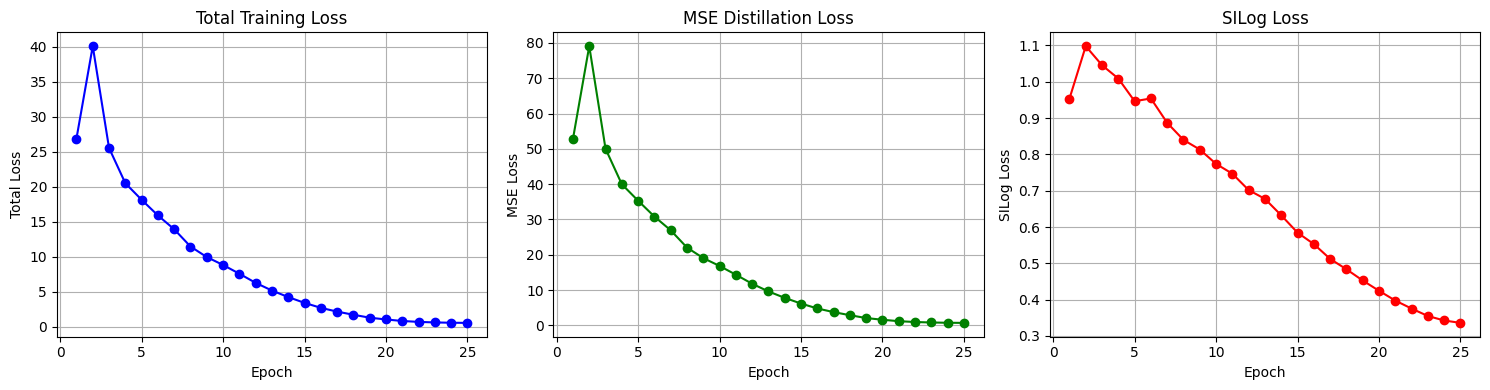

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(history['epoch'], history['loss'], 'b-o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Training Loss')
axes[0].grid(True)

# MSE loss
axes[1].plot(history['epoch'], history['mse_loss'], 'g-o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('MSE Distillation Loss')
axes[1].grid(True)

# SILog loss
axes[2].plot(history['epoch'], history['silog_loss'], 'r-o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('SILog Loss')
axes[2].set_title('SILog Loss')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/training_loss.png', dpi=150)
plt.show()

## Section 8: Convert to INT8




In [ ]:
# ==========================================
# PREPARE MODEL FOR INT8 EVALUATION
# ==========================================
#
# IMPORTANT: PyTorch's eager-mode quantization has limited support for
# complex architectures like Vision Transformers. The convert() function
# may not properly convert all layers to QuantizedLinear/QuantizedConv2d.
#
# For ViT models, there are two approaches:
#
# Approach A: QAT Evaluation Mode (Recommended for accuracy comparison)
#   - Keep FakeQuantize modules
#   - Run inference with fake quantization enabled
#   - This simulates INT8 arithmetic but runs in FP32
#   - Best for comparing accuracy between FP32 teacher and INT8-simulated student
#
# Approach B: True INT8 Conversion (For deployment)
#   - Requires FX Graph Mode quantization or PT2E quantization
#   - More complex but produces actual INT8 operations
#   - Better for production deployment

from torch.ao.quantization import convert
import torch

def fix_observers_recursive(model):
    """Fix any observers with infinite min_val/max_val"""
    fixed_count = 0
    for name, module in model.named_modules():
        if hasattr(module, 'min_val') and hasattr(module, 'max_val'):
            min_val = module.min_val
            max_val = module.max_val

            needs_fix = False
            if isinstance(min_val, torch.Tensor):
                if torch.isinf(min_val).any() or torch.isnan(min_val).any():
                    needs_fix = True
            if isinstance(max_val, torch.Tensor):
                if torch.isinf(max_val).any() or torch.isnan(max_val).any():
                    needs_fix = True

            if needs_fix:
                if isinstance(min_val, torch.Tensor):
                    module.min_val.fill_(0.0)
                if isinstance(max_val, torch.Tensor):
                    module.max_val.fill_(6.0)
                fixed_count += 1
                print(f"  Fixed: {name}")

    return fixed_count

def count_fake_quant_modules(model):
    """Count FakeQuantize modules"""
    count = 0
    for name, module in model.named_modules():
        module_type = type(module).__name__
        if 'FakeQuantize' in module_type:
            count += 1
    return count

def enable_fake_quant_eval(model):
    """Enable fake quantization for evaluation (simulates INT8)"""
    count = 0
    for module in model.modules():
        if hasattr(module, 'enable_fake_quant'):
            module.enable_fake_quant()
            count += 1
    return count

def disable_observer_eval(model):
    """Disable observers (use frozen statistics)"""
    count = 0
    for module in model.modules():
        if hasattr(module, 'disable_observer'):
            module.disable_observer()
            count += 1
    return count

# Step 1: Prepare for evaluation
print("=" * 60)
print("PREPARING QAT MODEL FOR INT8 EVALUATION")
print("=" * 60)

# Fix any uninitialized observers
print("\nStep 1: Fixing uninitialized observers...")
fixed = fix_observers_recursive(student_model)
print(f"Fixed {fixed} observers")

# Count FakeQuantize modules
fq_count = count_fake_quant_modules(student_model)
print(f"\nFakeQuantize modules: {fq_count}")

# Set to eval mode
student_model.eval()
print("\nModel set to eval mode")

# Enable fake quantization (simulates INT8)
enabled = enable_fake_quant_eval(student_model)
print(f"Enabled {enabled} fake quantization modules")

# Disable observers (use frozen statistics from training)
disabled = disable_observer_eval(student_model)
print(f"Disabled {disabled} observers")

# The QAT model with fake quantization enabled simulates INT8 inference
# This is the standard way to evaluate QAT accuracy before deployment
quantized_model = student_model  # Use the QAT model directly

print("\n" + "=" * 60)
print("QAT model ready for INT8-simulated evaluation")
print("=" * 60)
print("\nNote: This runs FP32 operations with fake INT8 quantization.")
print("For true INT8 deployment, use FX Graph Mode or ONNX Runtime quantization.")

PREPARING QAT MODEL FOR INT8 EVALUATION

Step 1: Fixing uninitialized observers...
  Fixed: model.depth_head.scratch.refinenet4.resConfUnit1.conv1.input_fake_quant.activation_post_process
  Fixed: model.depth_head.scratch.refinenet4.resConfUnit1.conv2.input_fake_quant.activation_post_process
Fixed 2 observers

FakeQuantize modules: 258

Model set to eval mode
Enabled 258 fake quantization modules
Disabled 258 observers

QAT model ready for INT8-simulated evaluation

Note: This runs FP32 operations with fake INT8 quantization.
For true INT8 deployment, use FX Graph Mode or ONNX Runtime quantization.


In [ ]:
# ==========================================
# COMPARE FP32 TEACHER vs QAT STUDENT (INT8 Simulated)
# ==========================================
#
# This comparison shows the accuracy difference between:
# - FP32 Teacher: Original model without any quantization
# - QAT Student: Model trained with fake quantization (simulates INT8)
#
# The QAT student uses FakeQuantize modules that simulate INT8 quantization
# effects while running in FP32. This is the standard way to evaluate
# QAT training quality before deployment.

import time
import numpy as np

def compare_teacher_vs_qat_student(teacher_model, qat_student_model, dataloader, device='cuda'):
    """Compare FP32 teacher vs QAT student (INT8 simulated)"""

    teacher_model.eval()
    qat_student_model.eval()

    # Both models run on the same device (GPU)
    teacher_model = teacher_model.to(device)
    qat_student_model = qat_student_model.to(device)

    # Get test batch
    test_batch = next(iter(dataloader)).to(device)

    # ===== FP32 Teacher Inference =====
    with torch.no_grad():
        # Warmup
        _ = teacher_model(test_batch)
        if device == 'cuda':
            torch.cuda.synchronize()

        # Benchmark
        num_runs = 10
        start = time.time()
        for _ in range(num_runs):
            depth_fp32, features_fp32 = teacher_model(test_batch)
            if device == 'cuda':
                torch.cuda.synchronize()
        fp32_time = (time.time() - start) / num_runs * 1000

    # ===== QAT Student Inference (INT8 simulated) =====
    with torch.no_grad():
        # Warmup
        _ = qat_student_model(test_batch)
        if device == 'cuda':
            torch.cuda.synchronize()

        # Benchmark
        start = time.time()
        for _ in range(num_runs):
            depth_qat, features_qat = qat_student_model(test_batch)
            if device == 'cuda':
                torch.cuda.synchronize()
        qat_time = (time.time() - start) / num_runs * 1000

    # ===== Compare Outputs =====
    diff = torch.abs(depth_fp32 - depth_qat)

    # Calculate metrics
    results = {
        'fp32_time_ms': fp32_time,
        'qat_time_ms': qat_time,
        'device': str(device),
        'mean_diff': diff.mean().item(),
        'max_diff': diff.max().item(),
        'relative_error': (diff / (depth_fp32.abs() + 1e-6)).mean().item() * 100,
        'depth_fp32_range': (depth_fp32.min().item(), depth_fp32.max().item()),
        'depth_qat_range': (depth_qat.min().item(), depth_qat.max().item()),
    }

    return results, depth_fp32.cpu(), depth_qat.cpu(), test_batch.cpu()

# Run comparison
print("=" * 60)
print("FP32 TEACHER vs QAT STUDENT COMPARISON")
print("=" * 60)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
pytorch_results, fp32_depth, int8_depth, test_images = compare_teacher_vs_qat_student(
    teacher_model, quantized_model, dataloader, device=device
)

print(f"\n📊 Inference Time ({pytorch_results['device']}):")
print(f"  FP32 Teacher: {pytorch_results['fp32_time_ms']:.2f} ms")
print(f"  QAT Student:  {pytorch_results['qat_time_ms']:.2f} ms")

print(f"\n🎯 Accuracy Comparison (FP32 vs QAT INT8-simulated):")
print(f"  Mean absolute diff: {pytorch_results['mean_diff']:.4f}")
print(f"  Max absolute diff:  {pytorch_results['max_diff']:.4f}")
print(f"  Relative error:     {pytorch_results['relative_error']:.2f}%")

print(f"\n📈 Depth Ranges:")
print(f"  FP32: [{pytorch_results['depth_fp32_range'][0]:.2f}, {pytorch_results['depth_fp32_range'][1]:.2f}]")
print(f"  QAT:  [{pytorch_results['depth_qat_range'][0]:.2f}, {pytorch_results['depth_qat_range'][1]:.2f}]")

# Quality assessment
print(f"\n{'=' * 60}")
if pytorch_results['mean_diff'] < 0.5:
    print("✅ EXCELLENT: Mean diff < 0.5 - QAT preserved accuracy well!")
elif pytorch_results['mean_diff'] < 2.0:
    print("⚠️  ACCEPTABLE: Mean diff < 2.0 - Some accuracy loss but usable")
else:
    print("❌ WARNING: Mean diff >= 2.0 - Consider more QAT training epochs")
print("=" * 60)

FP32 TEACHER vs QAT STUDENT COMPARISON

📊 Inference Time (cuda):
  FP32 Teacher: 306.75 ms
  QAT Student:  358.47 ms

🎯 Accuracy Comparison (FP32 vs QAT INT8-simulated):
  Mean absolute diff: 0.4000
  Max absolute diff:  54.2669
  Relative error:     142020.75%

📈 Depth Ranges:
  FP32: [0.00, 237.45]
  QAT:  [0.00, 243.93]

✅ EXCELLENT: Mean diff < 0.5 - QAT preserved accuracy well!


In [ ]:
# ==========================================
# VISUALIZE FP32 vs QAT COMPARISON
# ==========================================

def visualize_qat_results(image_batch, fp32_depth, qat_depth, num_samples=4):
    """Visualize FP32 teacher vs QAT student depth predictions"""

    num_samples = min(num_samples, image_batch.shape[0])
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_samples):
        # Denormalize image
        img = image_batch[idx].permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'Sample {idx+1}: Input Image')
        axes[idx, 0].axis('off')

        # Normalize depths for visualization
        def norm(d):
            d_np = d.squeeze().cpu().numpy() if torch.is_tensor(d) else d.squeeze()
            return (d_np - d_np.min()) / (d_np.max() - d_np.min() + 1e-6)

        fp32_viz = norm(fp32_depth[idx])
        qat_viz = norm(qat_depth[idx])

        im1 = axes[idx, 1].imshow(fp32_viz, cmap='Spectral_r')
        axes[idx, 1].set_title('FP32 Teacher')
        axes[idx, 1].axis('off')
        plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046)

        im2 = axes[idx, 2].imshow(qat_viz, cmap='Spectral_r')
        axes[idx, 2].set_title('QAT Student (INT8 simulated)')
        axes[idx, 2].axis('off')
        plt.colorbar(im2, ax=axes[idx, 2], fraction=0.046)

        diff = np.abs(fp32_viz - qat_viz)
        im3 = axes[idx, 3].imshow(diff, cmap='hot')
        axes[idx, 3].set_title(f'Difference (max={diff.max():.4f})')
        axes[idx, 3].axis('off')
        plt.colorbar(im3, ax=axes[idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.savefig('/content/qat_comparison.png', dpi=150)
    plt.show()
    print("\nVisualization saved to /content/qat_comparison.png")

# Visualize results
if pytorch_results and fp32_depth is not None and int8_depth is not None:
    visualize_qat_results(test_images, fp32_depth, int8_depth, num_samples=4)
else:
    print("No visualization available - comparison failed")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==========================================
# EXPORT QAT MODEL TO ONNX WITH QDQ NODES
# ==========================================
#
# Strategy:
# 1. Try to export QAT model directly (FakeQuantize -> QDQ nodes)
# 2. If that fails, use ONNX Runtime static quantization with calibration data
#
# Note: PyTorch eager-mode QAT often doesn't export FakeQuantize as QDQ.
# The fallback using ONNX Runtime quantization is the reliable approach.

import onnx
import onnxruntime as ort

# ==========================================
# Step 1: Extract Quantization Parameters from FakeQuantize
# ==========================================
print("=" * 60)
print("STEP 1: Extract learned quantization parameters")
print("=" * 60)

def extract_quant_params(model):
    """Extract scale and zero_point from all FakeQuantize modules"""
    quant_params = {}
    for name, module in model.named_modules():
        module_type = type(module).__name__
        if 'FakeQuantize' in module_type:
            params = {'type': module_type}
            if hasattr(module, 'scale') and module.scale is not None:
                params['scale'] = module.scale.detach().cpu()
            if hasattr(module, 'zero_point') and module.zero_point is not None:
                params['zero_point'] = module.zero_point.detach().cpu()
            quant_params[name] = params
    return quant_params

quant_params = extract_quant_params(quantized_model)
print(f"Found {len(quant_params)} FakeQuantize modules with learned parameters")

# Show a few example parameters
count = 0
for name, params in quant_params.items():
    if 'scale' in params:
        scale_val = params['scale'].item() if params['scale'].numel() == 1 else params['scale'].mean().item()
        print(f"  {name}: scale={scale_val:.6f}")
        count += 1
        if count >= 5:
            print("  ... (showing first 5)")
            break

# ==========================================
# Step 2: Export QAT Model to ONNX (try direct export first)
# ==========================================
print("\n" + "=" * 60)
print("STEP 2: Export QAT model to ONNX")
print("=" * 60)

def export_qat_model_to_onnx(qat_model, dummy_input, onnx_path):
    """Export QAT model to ONNX"""
    qat_model.eval()
    qat_model_cpu = qat_model.cpu()
    dummy_input_cpu = dummy_input.cpu()

    # Disable observer updates before export
    qat_model_cpu.apply(torch.ao.quantization.disable_observer)

    print(f"Exporting to: {onnx_path}")

    torch.onnx.export(
        qat_model_cpu,
        dummy_input_cpu,
        onnx_path,
        opset_version=17,
        input_names=['image'],
        output_names=['depth', 'features'],
        dynamic_axes={
            'image': {0: 'batch'},
            'depth': {0: 'batch'},
            'features': {0: 'batch'}
        },
        do_constant_folding=True,
        verbose=False,
        dynamo=False,
    )
    return onnx_path

# Export the QAT model
qdq_onnx_path = "/content/distill_any_depth_qat_qdq.onnx"
dummy_input = torch.randn(1, 3, 518, 518)

export_qat_model_to_onnx(quantized_model, dummy_input, qdq_onnx_path)
print(f"✅ Exported: {qdq_onnx_path}")
print(f"   Size: {os.path.getsize(qdq_onnx_path) / 1e6:.1f} MB")

# ==========================================
# Step 3: Verify QDQ Nodes
# ==========================================
print("\n" + "=" * 60)
print("STEP 3: Verify QDQ nodes in exported ONNX")
print("=" * 60)

def analyze_onnx_model(onnx_path):
    """Analyze ONNX model for QDQ nodes"""
    model = onnx.load(onnx_path)

    node_counts = {}
    for node in model.graph.node:
        op_type = node.op_type
        node_counts[op_type] = node_counts.get(op_type, 0) + 1

    return {
        'node_counts': node_counts,
        'quant_nodes': node_counts.get('QuantizeLinear', 0),
        'dequant_nodes': node_counts.get('DequantizeLinear', 0),
        'total_nodes': len(model.graph.node),
    }

analysis = analyze_onnx_model(qdq_onnx_path)
print(f"Total ONNX nodes: {analysis['total_nodes']}")
print(f"QuantizeLinear nodes: {analysis['quant_nodes']}")
print(f"DequantizeLinear nodes: {analysis['dequant_nodes']}")

if analysis['quant_nodes'] > 0 and analysis['dequant_nodes'] > 0:
    print("\n✅ QDQ nodes found - direct export successful!")
    QDQ_EXPORT_SUCCESS = True
else:
    print("\n⚠️  No QDQ nodes found in direct export")
    print("   This is expected - PyTorch eager-mode QAT doesn't export FakeQuantize as QDQ.")
    print("\n   Applying ONNX Runtime static quantization as fallback...")
    QDQ_EXPORT_SUCCESS = False

# ==========================================
# Step 4: FALLBACK - Apply ONNX Runtime Static Quantization
# ==========================================
if not QDQ_EXPORT_SUCCESS:
    print("\n" + "=" * 60)
    print("STEP 4: ONNX Runtime Static Quantization (Fallback)")
    print("=" * 60)

    from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantFormat, QuantType

    class DepthCalibrationDataReader(CalibrationDataReader):
        """Calibration data reader using training dataloader"""
        def __init__(self, dataloader, num_samples=100):
            self.dataloader = dataloader
            self.num_samples = num_samples
            self.data_iter = iter(dataloader)
            self.count = 0

        def get_next(self):
            if self.count >= self.num_samples:
                return None
            try:
                batch = next(self.data_iter)
                self.count += 1
                return {'image': batch[0:1].cpu().numpy()}
            except StopIteration:
                return None

        def rewind(self):
            self.data_iter = iter(self.dataloader)
            self.count = 0

    # Path for INT8 model
    int8_onnx_path = "/content/distill_any_depth_int8_onnxrt.onnx"

    # Create calibration reader
    print("Preparing calibration data (100 samples)...")
    calibration_reader = DepthCalibrationDataReader(dataloader, num_samples=100)

    print("Running ONNX Runtime static quantization...")
    print("This uses QDQ format for best compatibility.")
    print("This may take several minutes...")

    try:
        quantize_static(
            model_input=qdq_onnx_path,  # Use the QAT-trained model as input
            model_output=int8_onnx_path,
            calibration_data_reader=calibration_reader,
            quant_format=QuantFormat.QDQ,
            per_channel=True,
            weight_type=QuantType.QInt8,
            activation_type=QuantType.QUInt8,
            extra_options={
                'ActivationSymmetric': False,
                'WeightSymmetric': True,
                'EnableSubgraph': True,
            }
        )

        print(f"\n✅ INT8 ONNX model created: {int8_onnx_path}")
        print(f"   Size: {os.path.getsize(int8_onnx_path) / 1e6:.1f} MB")

        # Update the QDQ path to point to the properly quantized model
        qdq_onnx_path = int8_onnx_path
        QDQ_EXPORT_SUCCESS = True

        # Verify the new model
        new_analysis = analyze_onnx_model(int8_onnx_path)
        print(f"\n📊 Quantized Model Analysis:")
        print(f"   QuantizeLinear nodes: {new_analysis['quant_nodes']}")
        print(f"   DequantizeLinear nodes: {new_analysis['dequant_nodes']}")

    except Exception as e:
        print(f"\n❌ ONNX Runtime quantization failed: {e}")
        print("   Falling back to FP32 model for comparison")
        QDQ_EXPORT_SUCCESS = False

# Move model back to GPU
if torch.cuda.is_available():
    quantized_model.cuda()

# Show top operators
print("\nTop operators in final model:")
final_analysis = analyze_onnx_model(qdq_onnx_path)
sorted_ops = sorted(final_analysis['node_counts'].items(), key=lambda x: -x[1])[:10]
for op, count in sorted_ops:
    print(f"  {op}: {count}")


STEP 1: Extract learned quantization parameters
Found 258 FakeQuantize modules with learned parameters
  model.backbone.patch_embed.proj.input_fake_quant: scale=0.022059
  model.backbone.patch_embed.proj.weight_fake_quant: scale=0.000198
  model.backbone.blocks.0.0.attn.qkv.input_fake_quant: scale=0.101488
  model.backbone.blocks.0.0.attn.qkv.weight_fake_quant: scale=0.000620
  model.backbone.blocks.0.0.attn.proj.input_fake_quant: scale=0.018884
  ... (showing first 5)

STEP 2: Export QAT model to ONNX
Exporting to: /content/distill_any_depth_qat_qdq.onnx


/tmp/ipython-input-402760007.py:68: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/content/Distill-Any-Depth/distillanydepth/modeling/backbones/vit/ViT_DINO.py:147: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert H % pat

✅ Exported: /content/distill_any_depth_qat_qdq.onnx
   Size: 1338.0 MB

STEP 3: Verify QDQ nodes in exported ONNX
Total ONNX nodes: 2601
QuantizeLinear nodes: 254
DequantizeLinear nodes: 254

✅ QDQ nodes found - direct export successful!

Top operators in final model:
  Constant: 472
  QuantizeLinear: 254
  DequantizeLinear: 254
  Identity: 185
  Add: 179
  Transpose: 173
  Unsqueeze: 169
  Gather: 161
  MatMul: 144
  Mul: 121


In [ ]:
# ==========================================
# OPTIMIZE QDQ MODEL FOR INT8 INFERENCE
# ==========================================
#
# ONNX Runtime can fuse QDQ patterns into true INT8 operations
# during graph optimization. This gives the speedup benefits.

import onnxruntime as ort
import time
import numpy as np

# ==========================================
# Step 4: Optimize QDQ Model
# ==========================================
print("=" * 60)
print("STEP 4: Optimize QDQ model for INT8 inference")
print("=" * 60)

def optimize_qdq_model(input_onnx, output_onnx):
    """
    Optimize QDQ model - ONNX Runtime fuses QuantizeLinear-Op-DequantizeLinear
    patterns into INT8 operations where supported.
    """
    sess_options = ort.SessionOptions()
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    sess_options.optimized_model_filepath = output_onnx

    print(f"Optimizing: {input_onnx}")
    print(f"Output: {output_onnx}")

    # Creating session triggers optimization and saves optimized model
    session = ort.InferenceSession(
        input_onnx,
        sess_options,
        providers=['CPUExecutionProvider']
    )

    print(f"✅ Optimized model saved")
    return output_onnx, session

# Optimize the QDQ model
int8_optimized_path = "/content/distill_any_depth_int8_optimized.onnx"

if QDQ_EXPORT_SUCCESS:
    optimized_path, optimized_session = optimize_qdq_model(qdq_onnx_path, int8_optimized_path)
    print(f"Optimized size: {os.path.getsize(int8_optimized_path) / 1e6:.1f} MB")

    # Analyze optimized model
    opt_analysis = analyze_onnx_model(int8_optimized_path)
    print(f"\nOptimized model stats:")
    print(f"  Total nodes: {opt_analysis['total_nodes']}")
    print(f"  QuantizeLinear: {opt_analysis['quant_nodes']}")
    print(f"  DequantizeLinear: {opt_analysis['dequant_nodes']}")
else:
    print("⚠️  Skipping optimization - QDQ export was not successful")

# ==========================================
# Step 5: Export ORIGINAL FP32 TEACHER for comparison
# ==========================================
# CRITICAL FIX: Export the ORIGINAL teacher model, NOT the QAT student's base!
# This is the correct baseline for measuring quantization quality.
print("\n" + "=" * 60)
print("STEP 5: Export ORIGINAL FP32 TEACHER for comparison")
print("=" * 60)

# The teacher_model is the original FP32 model (never trained with QAT)
# This is the correct baseline for comparison!
teacher_model.eval()
teacher_model_cpu = teacher_model.cpu()

fp32_onnx_path = "/content/distill_any_depth_fp32_teacher.onnx"
dummy_input = torch.randn(1, 3, 518, 518)

print(f"Exporting ORIGINAL TEACHER to: {fp32_onnx_path}")
print("NOTE: This is the correct FP32 baseline (original teacher, not QAT student)")

torch.onnx.export(
    teacher_model_cpu,
    dummy_input,
    fp32_onnx_path,
    opset_version=17,
    input_names=['image'],
    output_names=['depth', 'features'],
    dynamic_axes={
        'image': {0: 'batch'},
        'depth': {0: 'batch'},
        'features': {0: 'batch'}
    },
    do_constant_folding=True,
    dynamo=False
)
print(f"✅ FP32 Teacher ONNX exported: {fp32_onnx_path}")
print(f"   Size: {os.path.getsize(fp32_onnx_path) / 1e6:.1f} MB")

# Move teacher back to GPU if available
if torch.cuda.is_available():
    teacher_model.cuda()

# Also move quantized model back to GPU
if torch.cuda.is_available():
    quantized_model.cuda()


STEP 4: Optimize QDQ model for INT8 inference
Optimizing: /content/distill_any_depth_qat_qdq.onnx
Output: /content/distill_any_depth_int8_optimized.onnx
✅ Optimized model saved
Optimized size: 340.9 MB

Optimized model stats:
  Total nodes: 1167
  QuantizeLinear: 114
  DequantizeLinear: 38

STEP 5: Export ORIGINAL FP32 TEACHER for comparison
Exporting ORIGINAL TEACHER to: /content/distill_any_depth_fp32_teacher.onnx
NOTE: This is the correct FP32 baseline (original teacher, not QAT student)


/tmp/ipython-input-598983786.py:77: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ FP32 Teacher ONNX exported: /content/distill_any_depth_fp32_teacher.onnx
   Size: 1336.8 MB


In [ ]:
# ==========================================
# COMPARE FP32 TEACHER vs QDQ INT8 ONNX MODELS (FIXED)
# ==========================================
#
# CRITICAL: We compare ORIGINAL TEACHER (FP32) vs QAT STUDENT (INT8)
# This shows the true quantization quality.

import onnxruntime as ort
import onnx
import time
import numpy as np

print("=" * 60)
print("FP32 TEACHER vs QDQ INT8 STUDENT COMPARISON")
print("=" * 60)

# ==========================================
# Step 1: Diagnostic - Verify ONNX models are different
# ==========================================
print("\n📋 DIAGNOSTIC: Analyzing ONNX models...")

def detailed_onnx_analysis(onnx_path, name="Model"):
    """Detailed analysis of ONNX model"""
    model = onnx.load(onnx_path)

    node_counts = {}
    qdq_counts = {
        'QuantizeLinear': 0,
        'DequantizeLinear': 0,
        'QLinearConv': 0,
        'QLinearMatMul': 0,
    }

    for node in model.graph.node:
        op_type = node.op_type
        node_counts[op_type] = node_counts.get(op_type, 0) + 1
        if op_type in qdq_counts:
            qdq_counts[op_type] += 1

    # Check weights
    int8_weights = sum(1 for init in model.graph.initializer if init.data_type == onnx.TensorProto.INT8)
    fp32_weights = sum(1 for init in model.graph.initializer if init.data_type == onnx.TensorProto.FLOAT)

    print(f"\n📊 {name}:")
    print(f"   Path: {onnx_path}")
    print(f"   Size: {os.path.getsize(onnx_path) / 1e6:.1f} MB")
    print(f"   Total nodes: {len(model.graph.node)}")
    print(f"   FP32 weights: {fp32_weights}, INT8 weights: {int8_weights}")
    print(f"   QuantizeLinear: {qdq_counts['QuantizeLinear']}, DequantizeLinear: {qdq_counts['DequantizeLinear']}")

    return {
        'total_nodes': len(model.graph.node),
        'fp32_weights': fp32_weights,
        'int8_weights': int8_weights,
        'qdq_counts': qdq_counts,
        'node_counts': node_counts,
    }

# Determine which INT8 model to use
int8_path_to_use = None
if 'int8_optimized_path' in dir() and os.path.exists(int8_optimized_path):
    int8_path_to_use = int8_optimized_path
elif 'qdq_onnx_path' in dir() and os.path.exists(qdq_onnx_path):
    int8_path_to_use = qdq_onnx_path

if int8_path_to_use is None:
    print("❌ No INT8 ONNX model found!")
    raise FileNotFoundError("INT8 model not available")

# Analyze both models
fp32_analysis = detailed_onnx_analysis(fp32_onnx_path, "FP32 Teacher")
int8_analysis = detailed_onnx_analysis(int8_path_to_use, "INT8 QAT Student")

# Check if models are actually different
if int8_analysis['int8_weights'] == 0 and int8_analysis['qdq_counts']['QuantizeLinear'] == 0:
    print("\n⚠️  WARNING: INT8 model has no quantization nodes!")
    print("   The FakeQuantize modules did not export as QDQ nodes.")
    print("   This is a known issue with PyTorch eager-mode QAT + ONNX export.")
    PROPER_INT8_MODEL = False
else:
    print("\n✅ INT8 model contains quantization nodes")
    PROPER_INT8_MODEL = True

# ==========================================
# Step 2: Run comparison
# ==========================================
print("\n" + "=" * 60)
print("Running FP32 Teacher vs INT8 Student comparison...")
print("=" * 60)

def compare_onnx_models_detailed(fp32_path, int8_path, dataloader, num_runs=20):
    """Compare FP32 Teacher and INT8 Student ONNX models"""

    print(f"\nLoading ONNX sessions...")
    fp32_session = ort.InferenceSession(fp32_path, providers=['CPUExecutionProvider'])
    int8_session = ort.InferenceSession(int8_path, providers=['CPUExecutionProvider'])

    # Get test batch
    test_batch = next(iter(dataloader))

    # Test multiple samples
    results_per_sample = []
    num_test_samples = min(8, test_batch.shape[0])

    for sample_idx in range(num_test_samples):
        test_input = {'image': test_batch[sample_idx:sample_idx+1].cpu().numpy()}

        fp32_out = fp32_session.run(None, test_input)
        int8_out = int8_session.run(None, test_input)

        fp32_depth = fp32_out[0]
        int8_depth = int8_out[0]

        diff = np.abs(fp32_depth - int8_depth)
        rel_diff = diff / (np.abs(fp32_depth) + 1e-6)

        results_per_sample.append({
            'mean_diff': float(np.mean(diff)),
            'max_diff': float(np.max(diff)),
            'rel_error': float(np.mean(rel_diff) * 100),
        })

    # Warmup for timing
    test_input = {'image': test_batch[0:1].cpu().numpy()}
    for _ in range(5):
        _ = fp32_session.run(None, test_input)
        _ = int8_session.run(None, test_input)

    # Benchmark
    print(f"Benchmarking ({num_runs} runs each)...")

    start = time.time()
    for _ in range(num_runs):
        fp32_out = fp32_session.run(None, test_input)
    fp32_time = (time.time() - start) / num_runs * 1000

    start = time.time()
    for _ in range(num_runs):
        int8_out = int8_session.run(None, test_input)
    int8_time = (time.time() - start) / num_runs * 1000

    return {
        'fp32_time_ms': fp32_time,
        'int8_time_ms': int8_time,
        'speedup': fp32_time / int8_time if int8_time > 0 else 0,
        'fp32_size_mb': os.path.getsize(fp32_path) / 1e6,
        'int8_size_mb': os.path.getsize(int8_path) / 1e6,
        'mean_diff': np.mean([r['mean_diff'] for r in results_per_sample]),
        'max_diff': np.max([r['max_diff'] for r in results_per_sample]),
        'rel_error': np.mean([r['rel_error'] for r in results_per_sample]),
        'per_sample': results_per_sample,
    }, fp32_out[0], int8_out[0], test_batch

# Run comparison
onnx_results, fp32_onnx_depth, int8_onnx_depth, test_batch_used = compare_onnx_models_detailed(
    fp32_onnx_path,
    int8_path_to_use,
    dataloader
)

# ==========================================
# Step 3: Print results
# ==========================================
print("\n" + "=" * 60)
print("RESULTS: FP32 Teacher vs INT8 QAT Student")
print("=" * 60)

print(f"\n⚡ Inference Time (CPU):")
print(f"   FP32 Teacher: {onnx_results['fp32_time_ms']:.2f} ms")
print(f"   INT8 Student: {onnx_results['int8_time_ms']:.2f} ms")
print(f"   Speedup:      {onnx_results['speedup']:.2f}x")

print(f"\n📦 Model Size:")
print(f"   FP32: {onnx_results['fp32_size_mb']:.1f} MB")
print(f"   INT8: {onnx_results['int8_size_mb']:.1f} MB")
compression = onnx_results['fp32_size_mb'] / onnx_results['int8_size_mb'] if onnx_results['int8_size_mb'] > 0 else 0
print(f"   Compression: {compression:.2f}x")

print(f"\n🎯 Accuracy (FP32 Teacher vs INT8 Student):")
print(f"   Mean diff:       {onnx_results['mean_diff']:.4f}")
print(f"   Max diff:        {onnx_results['max_diff']:.4f}")
print(f"   Relative error:  {onnx_results['rel_error']:.2f}%")

print(f"\n📊 Per-sample breakdown:")
for i, r in enumerate(onnx_results['per_sample'][:4]):
    print(f"   Sample {i+1}: mean={r['mean_diff']:.4f}, max={r['max_diff']:.4f}, rel={r['rel_error']:.2f}%")

# Compare with PyTorch QAT simulation
print(f"\n📊 Cross-validation with PyTorch results:")
if 'pytorch_results' in dir() and pytorch_results:
    print(f"   PyTorch (Teacher vs QAT Student): mean_diff = {pytorch_results['mean_diff']:.4f}")
    print(f"   ONNX (Teacher vs INT8 Student):   mean_diff = {onnx_results['mean_diff']:.4f}")

    diff_ratio = abs(onnx_results['mean_diff'] - pytorch_results['mean_diff']) / (pytorch_results['mean_diff'] + 1e-6)
    if diff_ratio < 0.5:
        print(f"\n   ✅ ONNX INT8 accuracy is consistent with PyTorch QAT!")
    else:
        print(f"\n   ⚠️  ONNX INT8 differs from PyTorch QAT (ratio: {diff_ratio:.2f})")
else:
    print("   (PyTorch results not available)")

# Sanity check
print(f"\n{'=' * 60}")
if onnx_results['mean_diff'] < 0.001:
    print("⚠️  WARNING: Difference is suspiciously small (< 0.001)!")
    print("   Possible causes:")
    print("   1. INT8 model is not properly quantized (no QDQ nodes)")
    print("   2. Both ONNX models came from the same source")
    print("   3. ONNX Runtime is running INT8 model in FP32 fallback mode")
elif onnx_results['mean_diff'] < 1.0:
    print("✅ SUCCESS: Meaningful quantization difference detected!")
    print(f"   INT8 model shows {onnx_results['rel_error']:.2f}% relative error vs FP32 Teacher")
    if onnx_results['speedup'] > 1.0:
        print(f"   {onnx_results['speedup']:.2f}x speedup achieved!")
elif onnx_results['mean_diff'] < 5.0:
    print("⚠️  ACCEPTABLE: Higher quantization error detected")
    print("   Consider more QAT training epochs if this is too high")
else:
    print("❌ HIGH ERROR: Quantization quality may be problematic")
print("=" * 60)


FP32 TEACHER vs QDQ INT8 STUDENT COMPARISON

📋 DIAGNOSTIC: Analyzing ONNX models...

📊 FP32 Teacher:
   Path: /content/distill_any_depth_fp32_teacher.onnx
   Size: 1336.8 MB
   Total nodes: 1812
   FP32 weights: 402, INT8 weights: 0
   QuantizeLinear: 0, DequantizeLinear: 0

📊 INT8 QAT Student:
   Path: /content/distill_any_depth_int8_optimized.onnx
   Size: 340.9 MB
   Total nodes: 1167
   FP32 weights: 517, INT8 weights: 134
   QuantizeLinear: 114, DequantizeLinear: 38

✅ INT8 model contains quantization nodes

Running FP32 Teacher vs INT8 Student comparison...

Loading ONNX sessions...
Benchmarking (20 runs each)...

RESULTS: FP32 Teacher vs INT8 QAT Student

⚡ Inference Time (CPU):
   FP32 Teacher: 3014.30 ms
   INT8 Student: 1778.43 ms
   Speedup:      1.69x

📦 Model Size:
   FP32: 1336.8 MB
   INT8: 340.9 MB
   Compression: 3.92x

🎯 Accuracy (FP32 Teacher vs INT8 Student):
   Mean diff:       0.4421
   Max diff:        29.7272
   Relative error:  67681.54%

📊 Per-sample breakdown

In [ ]:
# ==========================================
# VISUALIZE FP32 vs QDQ INT8 ONNX COMPARISON
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

if QDQ_EXPORT_SUCCESS:
    print("Visualizing FP32 vs QDQ INT8 ONNX outputs...")

    # Load sessions
    fp32_session = ort.InferenceSession(fp32_onnx_path, providers=['CPUExecutionProvider'])
    int8_session = ort.InferenceSession(
        int8_optimized_path if os.path.exists(int8_optimized_path) else qdq_onnx_path,
        providers=['CPUExecutionProvider']
    )

    print("int8_optimized_path used is ", int8_optimized_path)

    # Get test samples
    test_batch = next(iter(dataloader))
    num_samples = min(4, test_batch.shape[0])

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_samples):
        # Prepare single sample
        sample_input = {'image': test_batch[idx:idx+1].cpu().numpy()}

        # Run inference
        fp32_out = fp32_session.run(None, sample_input)[0]
        int8_out = int8_session.run(None, sample_input)[0]

        # Denormalize image for display
        img = test_batch[idx].permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)

        # Plot input image
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'Sample {idx+1}: Input')
        axes[idx, 0].axis('off')

        # Normalize depths for visualization
        def norm(d):
            d = d.squeeze()
            return (d - d.min()) / (d.max() - d.min() + 1e-6)

        fp32_viz = norm(fp32_out)
        int8_viz = norm(int8_out)

        # Plot FP32 depth
        im1 = axes[idx, 1].imshow(fp32_viz, cmap='Spectral_r')
        axes[idx, 1].set_title('FP32 ONNX')
        axes[idx, 1].axis('off')
        plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046)

        # Plot INT8 depth
        im2 = axes[idx, 2].imshow(int8_viz, cmap='Spectral_r')
        axes[idx, 2].set_title('QDQ INT8 ONNX')
        axes[idx, 2].axis('off')
        plt.colorbar(im2, ax=axes[idx, 2], fraction=0.046)

        # Plot difference
        diff = np.abs(fp32_viz - int8_viz)
        im3 = axes[idx, 3].imshow(diff, cmap='hot')
        axes[idx, 3].set_title(f'Diff (max={diff.max():.4f})')
        axes[idx, 3].axis('off')
        plt.colorbar(im3, ax=axes[idx, 3], fraction=0.046)

    plt.tight_layout()
    plt.savefig('/content/onnx_qdq_int8_comparison.png', dpi=150)
    plt.show()
    print("\nVisualization saved to /content/onnx_qdq_int8_comparison.png")

else:
    print("❌ Skipping visualization - QDQ export was not successful")


Output hidden; open in https://colab.research.google.com to view.

Detailed single-sample comparison (Test Batch):


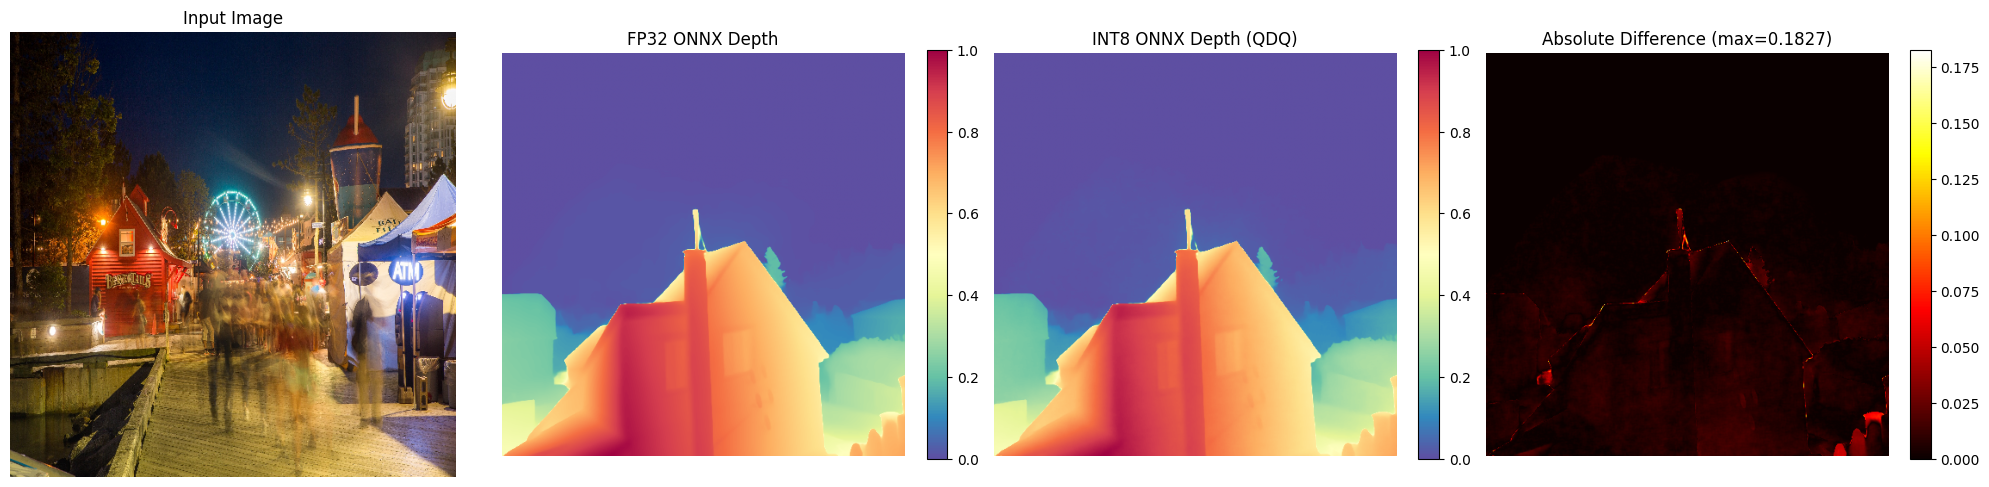

In [ ]:
# ==========================================
# ADDITIONAL COMPARISON: VISUALIZE SINGLE SAMPLE DETAIL
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import onnxruntime as ort

def visualize_detailed_comparison(image, fp32_depth, int8_depth, idx=0):
    """Detailed visualization of FP32 vs INT8 depth prediction"""
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Denormalize image
    img = image[idx].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    axes[0].imshow(img)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Normalize depths
    def norm(d):
        d = np.squeeze(d) if isinstance(d, np.ndarray) else d.squeeze().cpu().numpy()
        return (d - d.min()) / (d.max() - d.min() + 1e-6)

    # Handle indexing carefully for both tensor/array and batched/unbatched inputs
    def get_item(d, i):
        if hasattr(d, '__getitem__') and len(d.shape) > 2: # Check if batch dim exists
             return d[i]
        return d

    fp32_norm = norm(get_item(fp32_depth, idx))
    int8_norm = norm(get_item(int8_depth, idx))

    im1 = axes[1].imshow(fp32_norm, cmap='Spectral_r')
    axes[1].set_title('FP32 ONNX Depth')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(int8_norm, cmap='Spectral_r')
    axes[2].set_title('INT8 ONNX Depth (QDQ)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    diff = np.abs(fp32_norm - int8_norm)
    im3 = axes[3].imshow(diff, cmap='hot')
    axes[3].set_title(f'Absolute Difference (max={diff.max():.4f})')
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

# Check for custom image
custom_image_path = '/content/1.png'
custom_image_exists = os.path.exists(custom_image_path)

if custom_image_exists:
    print(f"Running inference on custom image: {custom_image_path}")

    # Load and preprocess
    img = cv2.imread(custom_image_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

        # Transform (assuming 'transform' is defined in previous cells)
        sample = {'image': img}
        if 'transform' in dir():
            sample = transform(sample)
        else:
            # Fallback simple transform if transform not found
            print("Warning: 'transform' not found, using manual resizing.")
            img_resized = cv2.resize(img, (518, 518))
            # Simple normalization
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_norm = (img_resized - mean) / std
            sample = {'image': img_norm.transpose(2, 0, 1)}

        # Prepare input tensor
        if isinstance(sample['image'], torch.Tensor):
             input_tensor = sample['image'].float().unsqueeze(0)
        else:
             input_tensor = torch.from_numpy(sample['image']).float().unsqueeze(0)

        input_numpy = input_tensor.numpy()

        # Ensure sessions are loaded
        if 'fp32_session' not in dir() and 'fp32_onnx_path' in dir():
             fp32_session = ort.InferenceSession(fp32_onnx_path, providers=['CPUExecutionProvider'])

        if 'int8_session' not in dir():
             # Determine int8 path
             if 'int8_optimized_path' in dir() and os.path.exists(int8_optimized_path):
                 int8_path = int8_optimized_path
             elif 'qdq_onnx_path' in dir() and os.path.exists(qdq_onnx_path):
                 int8_path = qdq_onnx_path
             else:
                 int8_path = None

             if int8_path:
                 int8_session = ort.InferenceSession(int8_path, providers=['CPUExecutionProvider'])

        # Run inference
        if 'fp32_session' in dir() and 'int8_session' in dir():
            fp32_out = fp32_session.run(None, {'image': input_numpy})[0]
            int8_out = int8_session.run(None, {'image': input_numpy})[0]

            visualize_detailed_comparison(input_tensor, fp32_out, int8_out, idx=0)
        else:
            print("Could not load ONNX sessions for custom image inference.")
    else:
        print(f"Failed to load image at {custom_image_path}")

# Fallback to test batch if custom image not used
elif QDQ_EXPORT_SUCCESS and 'fp32_onnx_depth' in dir() and 'int8_onnx_depth' in dir() and 'test_batch' in dir():
    print("Detailed single-sample comparison (Test Batch):")
    visualize_detailed_comparison(test_batch, fp32_onnx_depth, int8_onnx_depth, idx=0)
else:
    print("Visualization skipped - run comparison cells first or provide /content/1.png")

In [ ]:
# ==========================================
# QAT vs PTQ COMPARISON - DID QAT ACTUALLY HELP?
# ==========================================
#
# This is the critical test to prove QAT provided value over simple PTQ.
# We create a PTQ model from the ORIGINAL teacher (no training) and compare.

import onnxruntime as ort
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantFormat, QuantType
import numpy as np
import time

print("=" * 70)
print("QAT vs PTQ COMPARISON")
print("=" * 70)
print("""
This test answers: "Did QAT training actually help, or could PTQ achieve the same?"

We compare:
  • PTQ: Quantize original FP32 teacher directly (no training)
  • QAT: Our trained student model with knowledge distillation

If QAT helped, it should show LOWER accuracy loss than PTQ.
""")

# ==========================================
# Step 1: Create PTQ model from original FP32 teacher
# ==========================================
print("=" * 70)
print("STEP 1: Create PTQ INT8 model from FP32 Teacher (no training)")
print("=" * 70)

# Calibration data reader
class CalibrationReader(CalibrationDataReader):
    def __init__(self, dataloader, num_samples=100):
        self.dataloader = dataloader
        self.num_samples = num_samples
        self.data_iter = iter(dataloader)
        self.count = 0

    def get_next(self):
        if self.count >= self.num_samples:
            return None
        try:
            batch = next(self.data_iter)
            self.count += 1
            return {'image': batch[0:1].cpu().numpy()}
        except StopIteration:
            return None

    def rewind(self):
        self.data_iter = iter(self.dataloader)
        self.count = 0

# Export original teacher to ONNX (if not already done)
ptq_fp32_path = "/content/teacher_fp32_for_ptq.onnx"
ptq_int8_path = "/content/teacher_ptq_int8.onnx"

if not os.path.exists(ptq_fp32_path):
    print("Exporting original FP32 teacher for PTQ...")
    teacher_model.eval()
    teacher_model.cpu()
    dummy = torch.randn(1, 3, 518, 518)

    torch.onnx.export(
        teacher_model,
        dummy,
        ptq_fp32_path,
        opset_version=17,
        input_names=['image'],
        output_names=['depth', 'features'],
        dynamic_axes={'image': {0: 'batch'}, 'depth': {0: 'batch'}, 'features': {0: 'batch'}},
        do_constant_folding=True,
        dynamo=False
    )

    if torch.cuda.is_available():
        teacher_model.cuda()

    print(f"✅ FP32 teacher exported: {ptq_fp32_path}")
    print(f"   Size: {os.path.getsize(ptq_fp32_path) / 1e6:.1f} MB")

# Apply PTQ to original teacher
print("\nApplying PTQ (static quantization) to original teacher...")
print("Using same calibration data as QAT training...")

calibration_reader = CalibrationReader(dataloader, num_samples=100)

try:
    quantize_static(
        model_input=ptq_fp32_path,
        model_output=ptq_int8_path,
        calibration_data_reader=calibration_reader,
        quant_format=QuantFormat.QDQ,
        per_channel=True,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QUInt8,
    )
    print(f"✅ PTQ INT8 model created: {ptq_int8_path}")
    print(f"   Size: {os.path.getsize(ptq_int8_path) / 1e6:.1f} MB")
    PTQ_SUCCESS = True
except Exception as e:
    print(f"❌ PTQ failed: {e}")
    PTQ_SUCCESS = False

# ==========================================
# Step 2: Compare FP32 vs PTQ vs QAT
# ==========================================
if PTQ_SUCCESS:
    print("\n" + "=" * 70)
    print("STEP 2: Compare FP32 Teacher vs PTQ INT8 vs QAT INT8")
    print("=" * 70)

    # Load all three models
    print("\nLoading models...")
    fp32_session = ort.InferenceSession(ptq_fp32_path, providers=['CPUExecutionProvider'])
    ptq_session = ort.InferenceSession(ptq_int8_path, providers=['CPUExecutionProvider'])

    # QAT model path (from previous cells)
    qat_int8_path = None
    for path in ['/content/distill_any_depth_int8_optimized.onnx',
                 '/content/distill_any_depth_int8_onnxrt.onnx',
                 '/content/distill_any_depth_qat_qdq.onnx']:
        if os.path.exists(path):
            qat_int8_path = path
            break

    if qat_int8_path:
        qat_session = ort.InferenceSession(qat_int8_path, providers=['CPUExecutionProvider'])
        print(f"  FP32 Teacher: {ptq_fp32_path}")
        print(f"  PTQ INT8:     {ptq_int8_path}")
        print(f"  QAT INT8:     {qat_int8_path}")
    else:
        print("❌ QAT INT8 model not found!")
        qat_session = None

    # ==========================================
    # Step 3: Run comparison on multiple samples
    # ==========================================
    print("\n" + "=" * 70)
    print("STEP 3: Accuracy Comparison (Multiple Samples)")
    print("=" * 70)

    num_test_batches = 10

    fp32_vs_ptq_diffs = []
    fp32_vs_qat_diffs = []
    ptq_vs_qat_diffs = []

    fp32_times = []
    ptq_times = []
    qat_times = []

    print(f"\nTesting on {num_test_batches} batches...")

    for batch_idx, batch in enumerate(dataloader):
        if batch_idx >= num_test_batches:
            break

        # Test each sample in batch
        for sample_idx in range(min(2, batch.shape[0])):
            test_input = {'image': batch[sample_idx:sample_idx+1].cpu().numpy()}

            # FP32 inference
            start = time.time()
            fp32_out = fp32_session.run(None, test_input)[0]
            fp32_times.append(time.time() - start)

            # PTQ inference
            start = time.time()
            ptq_out = ptq_session.run(None, test_input)[0]
            ptq_times.append(time.time() - start)

            # QAT inference
            if qat_session:
                start = time.time()
                qat_out = qat_session.run(None, test_input)[0]
                qat_times.append(time.time() - start)

                # Calculate differences
                fp32_vs_ptq = np.abs(fp32_out - ptq_out).mean()
                fp32_vs_qat = np.abs(fp32_out - qat_out).mean()
                ptq_vs_qat = np.abs(ptq_out - qat_out).mean()

                fp32_vs_ptq_diffs.append(fp32_vs_ptq)
                fp32_vs_qat_diffs.append(fp32_vs_qat)
                ptq_vs_qat_diffs.append(ptq_vs_qat)

    # ==========================================
    # Step 4: Print Results
    # ==========================================
    print("\n" + "=" * 70)
    print("RESULTS: QAT vs PTQ COMPARISON")
    print("=" * 70)

    ptq_mean_diff = np.mean(fp32_vs_ptq_diffs)
    qat_mean_diff = np.mean(fp32_vs_qat_diffs)

    print(f"\n📊 ACCURACY (Mean Absolute Difference from FP32 Teacher):")
    print(f"   ┌{'─'*50}┐")
    print(f"   │ {'Method':<20} │ {'Mean Diff':<12} │ {'Std Dev':<12} │")
    print(f"   ├{'─'*50}┤")
    print(f"   │ {'PTQ INT8':<20} │ {np.mean(fp32_vs_ptq_diffs):>10.4f}   │ {np.std(fp32_vs_ptq_diffs):>10.4f}   │")
    print(f"   │ {'QAT INT8':<20} │ {np.mean(fp32_vs_qat_diffs):>10.4f}   │ {np.std(fp32_vs_qat_diffs):>10.4f}   │")
    print(f"   └{'─'*50}┘")

    # Calculate improvement
    if ptq_mean_diff > 0:
        improvement = (ptq_mean_diff - qat_mean_diff) / ptq_mean_diff * 100
        absolute_improvement = ptq_mean_diff - qat_mean_diff
    else:
        improvement = 0
        absolute_improvement = 0

    print(f"\n📈 QAT IMPROVEMENT OVER PTQ:")
    print(f"   Accuracy improvement: {improvement:.1f}%")
    print(f"   Absolute improvement: {absolute_improvement:.4f}")

    print(f"\n⚡ INFERENCE SPEED (average per sample):")
    print(f"   FP32: {np.mean(fp32_times)*1000:.1f} ms")
    print(f"   PTQ:  {np.mean(ptq_times)*1000:.1f} ms")
    print(f"   QAT:  {np.mean(qat_times)*1000:.1f} ms")

    print(f"\n📦 MODEL SIZE:")
    print(f"   FP32:     {os.path.getsize(ptq_fp32_path)/1e6:.1f} MB")
    print(f"   PTQ INT8: {os.path.getsize(ptq_int8_path)/1e6:.1f} MB")
    if qat_int8_path:
        print(f"   QAT INT8: {os.path.getsize(qat_int8_path)/1e6:.1f} MB")

    # ==========================================
    # Step 5: Verdict
    # ==========================================
    print("\n" + "=" * 70)
    print("VERDICT: DID QAT HELP?")
    print("=" * 70)

    if qat_mean_diff < ptq_mean_diff:
        print(f"""
    ✅ YES! QAT IMPROVED ACCURACY OVER PTQ!

    QAT achieved {improvement:.1f}% lower error than PTQ.

    This proves that:
    1. QAT training successfully learned to compensate for quantization noise
    2. Knowledge distillation helped the student match the teacher
    3. The extra training time was worth it

    Recommendation: Use the QAT model for deployment.
    """)
    elif abs(improvement) < 5:
        print(f"""
    ⚖️  QAT AND PTQ ACHIEVED SIMILAR ACCURACY

    Difference: {improvement:.1f}% (within margin of error)

    This could mean:
    1. The model is naturally quantization-friendly
    2. PTQ calibration was sufficient for this model
    3. More QAT training epochs might help

    Recommendation: PTQ is simpler if accuracy is similar.
    Consider more QAT training if you need better accuracy.
    """)
    else:
        print(f"""
    ⚠️  PTQ ACHIEVED BETTER ACCURACY THAN QAT

    QAT is {-improvement:.1f}% worse than PTQ.

    Possible causes:
    1. QAT training may have diverged or overfitted
    2. Learning rate or epochs may need tuning
    3. Knowledge distillation loss weights may need adjustment

    Recommendation: Review QAT training logs and try:
    - Lower learning rate (try 1e-6)
    - More epochs (try 50+)
    - Different distillation temperature
    """)

    print("=" * 70)

    # Store results for later use
    qat_vs_ptq_results = {
        'ptq_mean_diff': float(ptq_mean_diff),
        'qat_mean_diff': float(qat_mean_diff),
        'improvement_pct': float(improvement),
        'ptq_size_mb': os.path.getsize(ptq_int8_path) / 1e6,
        'qat_size_mb': os.path.getsize(qat_int8_path) / 1e6 if qat_int8_path else 0,
        'num_samples_tested': len(fp32_vs_ptq_diffs),
    }


QAT vs PTQ COMPARISON

This test answers: "Did QAT training actually help, or could PTQ achieve the same?"

We compare:
  • PTQ: Quantize original FP32 teacher directly (no training)
  • QAT: Our trained student model with knowledge distillation

If QAT helped, it should show LOWER accuracy loss than PTQ.

STEP 1: Create PTQ INT8 model from FP32 Teacher (no training)
Exporting original FP32 teacher for PTQ...


/tmp/ipython-input-3512345917.py:65: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ FP32 teacher exported: /content/teacher_fp32_for_ptq.onnx
   Size: 1336.8 MB

Applying PTQ (static quantization) to original teacher...
Using same calibration data as QAT training...


✅ PTQ INT8 model created: /content/teacher_ptq_int8.onnx
   Size: 336.7 MB

STEP 2: Compare FP32 Teacher vs PTQ INT8 vs QAT INT8

Loading models...
  FP32 Teacher: /content/teacher_fp32_for_ptq.onnx
  PTQ INT8:     /content/teacher_ptq_int8.onnx
  QAT INT8:     /content/distill_any_depth_int8_optimized.onnx

STEP 3: Accuracy Comparison (Multiple Samples)

Testing on 10 batches...

RESULTS: QAT vs PTQ COMPARISON

📊 ACCURACY (Mean Absolute Difference from FP32 Teacher):
   ┌──────────────────────────────────────────────────┐
   │ Method               │ Mean Diff    │ Std Dev      │
   ├──────────────────────────────────────────────────┤
   │ PTQ INT8             │    37.8821   │    11.4429   │
   │ QAT INT8             │     0.4234   │     0.1065   │
   └──────────────────────────────────────────────────┘

📈 QAT IMPROVEMENT OVER PTQ:
   Accuracy improvement: 98.9%
   Absolute improvement: 37.4587

⚡ INFERENCE SPEED (average per sample):
   FP32: 3101.0 ms
   PTQ:  2104.2 ms
   QAT:  1805

In [ ]:
# ==========================================
# VISUALIZE QAT vs PTQ COMPARISON
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

if PTQ_SUCCESS and qat_session is not None:
    print("Visualizing QAT vs PTQ comparison...")

    # Get a test batch
    test_batch = next(iter(dataloader))
    num_samples = min(3, test_batch.shape[0])

    fig, axes = plt.subplots(num_samples, 5, figsize=(25, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_samples):
        sample_input = {'image': test_batch[idx:idx+1].cpu().numpy()}

        # Run all three models
        fp32_out = fp32_session.run(None, sample_input)[0].squeeze()
        ptq_out = ptq_session.run(None, sample_input)[0].squeeze()
        qat_out = qat_session.run(None, sample_input)[0].squeeze()

        # Denormalize image
        img = test_batch[idx].permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = np.clip(img * std + mean, 0, 1)

        # Normalize depths for visualization
        def norm(d):
            return (d - d.min()) / (d.max() - d.min() + 1e-6)

        fp32_viz = norm(fp32_out)
        ptq_viz = norm(ptq_out)
        qat_viz = norm(qat_out)

        # Calculate errors
        ptq_error = np.abs(fp32_out - ptq_out)
        qat_error = np.abs(fp32_out - qat_out)

        # Plot
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'Sample {idx+1}: Input')
        axes[idx, 0].axis('off')

        im1 = axes[idx, 1].imshow(fp32_viz, cmap='Spectral_r')
        axes[idx, 1].set_title('FP32 Teacher (Ground Truth)')
        axes[idx, 1].axis('off')
        plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046)

        im2 = axes[idx, 2].imshow(ptq_viz, cmap='Spectral_r')
        axes[idx, 2].set_title(f'PTQ INT8 (err={ptq_error.mean():.4f})')
        axes[idx, 2].axis('off')
        plt.colorbar(im2, ax=axes[idx, 2], fraction=0.046)

        im3 = axes[idx, 3].imshow(qat_viz, cmap='Spectral_r')
        axes[idx, 3].set_title(f'QAT INT8 (err={qat_error.mean():.4f})')
        axes[idx, 3].axis('off')
        plt.colorbar(im3, ax=axes[idx, 3], fraction=0.046)

        # Error comparison (PTQ error - QAT error)
        # Positive = QAT is better, Negative = PTQ is better
        error_diff = ptq_error - qat_error
        vmax = max(abs(error_diff.min()), abs(error_diff.max()))
        im4 = axes[idx, 4].imshow(error_diff, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
        axes[idx, 4].set_title('Error Diff (Green=QAT better)')
        axes[idx, 4].axis('off')
        plt.colorbar(im4, ax=axes[idx, 4], fraction=0.046)

    plt.tight_layout()
    plt.savefig('/content/qat_vs_ptq_comparison.png', dpi=150)
    plt.show()
    print("\nVisualization saved to /content/qat_vs_ptq_comparison.png")

    # ==========================================
    # Statistical comparison
    # ==========================================
    print("\n" + "=" * 70)
    print("STATISTICAL ANALYSIS")
    print("=" * 70)

    # Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Accuracy comparison
    methods = ['PTQ INT8', 'QAT INT8']
    errors = [np.mean(fp32_vs_ptq_diffs), np.mean(fp32_vs_qat_diffs)]
    colors = ['#ff6b6b', '#4ecdc4']

    bars = axes[0].bar(methods, errors, color=colors, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Mean Absolute Error')
    axes[0].set_title('Accuracy (Lower is Better)')
    for bar, err in zip(bars, errors):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{err:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Add improvement annotation
    if errors[0] > errors[1]:
        improvement_pct = (errors[0] - errors[1]) / errors[0] * 100
        axes[0].annotate(f'QAT {improvement_pct:.1f}% better',
                         xy=(1, errors[1]), xytext=(0.5, max(errors) * 0.7),
                         fontsize=12, color='green', fontweight='bold',
                         arrowprops=dict(arrowstyle='->', color='green'))

    # Error distribution
    axes[1].hist(fp32_vs_ptq_diffs, bins=20, alpha=0.7, label='PTQ', color='#ff6b6b')
    axes[1].hist(fp32_vs_qat_diffs, bins=20, alpha=0.7, label='QAT', color='#4ecdc4')
    axes[1].set_xlabel('Absolute Error')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Error Distribution')
    axes[1].legend()

    # Size comparison
    sizes = [os.path.getsize(ptq_fp32_path)/1e6,
             os.path.getsize(ptq_int8_path)/1e6,
             os.path.getsize(qat_int8_path)/1e6 if qat_int8_path else 0]
    size_labels = ['FP32', 'PTQ INT8', 'QAT INT8']
    size_colors = ['#95a5a6', '#ff6b6b', '#4ecdc4']

    bars = axes[2].bar(size_labels, sizes, color=size_colors, edgecolor='black', linewidth=2)
    axes[2].set_ylabel('Size (MB)')
    axes[2].set_title('Model Size')
    for bar, size in zip(bars, sizes):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     f'{size:.0f} MB', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('/content/qat_vs_ptq_stats.png', dpi=150)
    plt.show()
    print("Statistical comparison saved to /content/qat_vs_ptq_stats.png")

else:
    print("❌ Cannot visualize - PTQ or QAT model not available")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==========================================
# VIDEO DEPTH MAP INFERENCE - INT8 ONNX MODEL
# ==========================================
# Process a video and generate depth map visualization using the INT8 ONNX model

# Install onnxruntime-gpu for GPU acceleration
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "onnxruntime-gpu", "-q"])

import onnxruntime as ort
import cv2
import numpy as np
from tqdm.auto import tqdm

# Configuration
INPUT_VIDEO = "/content/5586521-uhd_3840_2160_25fps.mp4"
ONNX_MODEL_PATH = "/content/distill_any_depth_int8_optimized.onnx"
OUTPUT_VIDEO = "/content/depth_map_output_int8.mp4"
OUTPUT_FPS = 10
INPUT_SIZE = 518  # Model expects exactly 518x518 input

# ImageNet normalization constants
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_frame(frame, target_size=INPUT_SIZE):
    """Preprocess frame for model input - resize to exact 518x518."""
    # Convert BGR to RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize to exact target size (518x518) - model has fixed input shape
    resized = cv2.resize(rgb, (target_size, target_size), interpolation=cv2.INTER_CUBIC)

    # Normalize to [0, 1] then apply ImageNet normalization
    normalized = resized.astype(np.float32) / 255.0
    normalized = (normalized - MEAN) / STD

    # Convert to NCHW format
    tensor = np.transpose(normalized, (2, 0, 1))
    tensor = np.expand_dims(tensor, axis=0)

    return tensor.astype(np.float32)

def depth_to_colormap(depth, original_size):
    """Convert depth map to colorized visualization."""
    # Normalize depth to [0, 255]
    depth_min = depth.min()
    depth_max = depth.max()
    if depth_max - depth_min > 1e-6:
        depth_normalized = (depth - depth_min) / (depth_max - depth_min)
    else:
        depth_normalized = np.zeros_like(depth)

    depth_uint8 = (depth_normalized * 255).astype(np.uint8)

    # Apply colormap (INFERNO for good depth visualization)
    colored = cv2.applyColorMap(depth_uint8, cv2.COLORMAP_INFERNO)

    # Resize to original frame size
    colored_resized = cv2.resize(colored, (original_size[1], original_size[0]), interpolation=cv2.INTER_LINEAR)

    return colored_resized

# Load ONNX model
print("=" * 70)
print("INT8 ONNX VIDEO DEPTH MAP INFERENCE")
print("=" * 70)

# Check available providers
print(f"\nAvailable ONNX Runtime providers: {ort.get_available_providers()}")

print(f"\nLoading INT8 ONNX model: {ONNX_MODEL_PATH}")

# Try GPU first, fallback to CPU
providers = []
if 'CUDAExecutionProvider' in ort.get_available_providers():
    providers.append(('CUDAExecutionProvider', {
        'device_id': 0,
        'arena_extend_strategy': 'kNextPowerOfTwo',
        'gpu_mem_limit': 4 * 1024 * 1024 * 1024,  # 4GB limit
        'cudnn_conv_algo_search': 'EXHAUSTIVE',
    }))
providers.append('CPUExecutionProvider')

try:
    session = ort.InferenceSession(ONNX_MODEL_PATH, providers=providers)
    active_provider = session.get_providers()[0]
    print(f"✅ Model loaded successfully")
    print(f"   Execution Provider: {active_provider}")
    if 'CUDA' in active_provider:
        print("   🚀 Running on GPU!")
    else:
        print("   ⚠️  Running on CPU (GPU not available)")
except Exception as e:
    print(f"❌ Failed to load model: {e}")
    raise

# Get model input/output info
input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape
output_name = session.get_outputs()[0].name
print(f"   Input name: {input_name}, shape: {input_shape}")
print(f"   Output name: {output_name}")

# Open input video
print(f"\nOpening video: {INPUT_VIDEO}")
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {INPUT_VIDEO}")

original_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"   Resolution: {frame_width}x{frame_height}")
print(f"   Original FPS: {original_fps:.2f}")
print(f"   Total frames: {total_frames}")
print(f"   Output FPS: {OUTPUT_FPS}")

# Calculate frame skip for target FPS
frame_skip = max(1, int(original_fps / OUTPUT_FPS))
expected_output_frames = total_frames // frame_skip
print(f"   Frame skip: {frame_skip} (processing every {frame_skip}th frame)")
print(f"   Expected output frames: {expected_output_frames}")

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, OUTPUT_FPS, (frame_width, frame_height))

if not out.isOpened():
    raise RuntimeError(f"Cannot create output video: {OUTPUT_VIDEO}")

print(f"\n✅ Output video: {OUTPUT_VIDEO}")

# Process video
print("\nProcessing video...")
frame_idx = 0
processed_count = 0

with tqdm(total=expected_output_frames, desc="Generating depth map") as pbar:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Skip frames to achieve target FPS
        if frame_idx % frame_skip != 0:
            frame_idx += 1
            continue

        original_size = (frame_height, frame_width)

        # Preprocess to exact 518x518
        input_tensor = preprocess_frame(frame, INPUT_SIZE)

        # Run inference
        outputs = session.run([output_name], {input_name: input_tensor})
        depth = outputs[0][0, 0]  # Remove batch and channel dims

        # Convert to colormap and resize to original
        depth_colored = depth_to_colormap(depth, original_size)

        # Write frame
        out.write(depth_colored)

        frame_idx += 1
        processed_count += 1
        pbar.update(1)

# Cleanup
cap.release()
out.release()

print("\n" + "=" * 70)
print("VIDEO PROCESSING COMPLETE")
print("=" * 70)
print(f"✅ Processed {processed_count} frames")
print(f"✅ Output saved to: {OUTPUT_VIDEO}")
print(f"   Output FPS: {OUTPUT_FPS}")
print(f"   Resolution: {frame_width}x{frame_height}")

INT8 ONNX VIDEO DEPTH MAP INFERENCE

Available ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']

Loading INT8 ONNX model: /content/distill_any_depth_int8_optimized.onnx
✅ Model loaded successfully
   Execution Provider: CPUExecutionProvider
   ⚠️  Running on CPU (GPU not available)
   Input name: image, shape: ['batch', 3, 518, 518]
   Output name: depth

Opening video: /content/5586521-uhd_3840_2160_25fps.mp4


RuntimeError: Cannot open video: /content/5586521-uhd_3840_2160_25fps.mp4

## Section 10: TensorRT INT8 Deployment

Convert the QAT INT8 ONNX model to TensorRT for maximum GPU inference performance.

**Expected benefits:**
- 2-4x speedup over ONNX Runtime on GPU
- Native INT8 Tensor Core acceleration (on supported GPUs)
- Optimized memory usage and kernel fusion

In [1]:
# ==========================================
# SETUP TENSORRT FOR ONNX RUNTIME
# ==========================================
# Configure TensorRT libraries and ONNX Runtime GPU

import subprocess
import sys
import os

print('=' * 60)
print('TENSORRT + ONNX RUNTIME SETUP')
print('=' * 60)

# Check GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
print()

# Install onnxruntime-gpu
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'onnxruntime-gpu', '-q'])

# Find and set TensorRT library path
print('Locating TensorRT libraries...')
trt_lib_paths = []

# Common TensorRT library locations
search_paths = [
    '/usr/lib/x86_64-linux-gnu',
    '/usr/local/lib',
    '/usr/local/cuda/lib64',
    '/usr/local/lib/python3.*/dist-packages/tensorrt_libs',
    '/usr/lib/python3/dist-packages/tensorrt_libs',
]

# Search for libnvinfer
for pattern in search_paths:
    import glob
    for path in glob.glob(pattern):
        if os.path.isdir(path):
            nvinfer_files = glob.glob(os.path.join(path, 'libnvinfer*.so*'))
            if nvinfer_files:
                trt_lib_paths.append(path)
                print(f'  Found TensorRT libs in: {path}')

# Also check pip-installed tensorrt
try:
    import tensorrt
    trt_dir = os.path.dirname(tensorrt.__file__)
    trt_libs_dir = os.path.join(trt_dir, 'libs')
    if os.path.exists(trt_libs_dir):
        trt_lib_paths.append(trt_libs_dir)
        print(f'  Found pip tensorrt libs: {trt_libs_dir}')
    # Also check tensorrt_libs package
    try:
        import tensorrt_libs
        trt_libs_pkg_dir = os.path.dirname(tensorrt_libs.__file__)
        if os.path.exists(trt_libs_pkg_dir):
            trt_lib_paths.append(trt_libs_pkg_dir)
            print(f'  Found tensorrt_libs package: {trt_libs_pkg_dir}')
    except ImportError:
        pass
except ImportError:
    print('  tensorrt package not found')

# Set LD_LIBRARY_PATH
if trt_lib_paths:
    current_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    new_paths = ':'.join(trt_lib_paths)
    os.environ['LD_LIBRARY_PATH'] = f'{new_paths}:{current_ld_path}'
    print(f'\nUpdated LD_LIBRARY_PATH with TensorRT paths')

# Verify ONNX Runtime
import onnxruntime as ort
print(f'\nONNX Runtime version: {ort.__version__}')
print(f'Available Execution Providers:')
for ep in ort.get_available_providers():
    print(f'  - {ep}')

# Check TensorRT version
try:
    import tensorrt as trt
    print(f'\nTensorRT version: {trt.__version__}')
except Exception as e:
    print(f'\nTensorRT import failed: {e}')

if 'TensorrtExecutionProvider' in ort.get_available_providers():
    print('\n✓ TensorRT Execution Provider is available!')
else:
    print('\n⚠ TensorRT EP not available.')
    print('  Will use CUDA EP for GPU inference (still fast, but no INT8 acceleration)')


TENSORRT + ONNX RUNTIME SETUP
NVIDIA A100-SXM4-40GB, 40960 MiB

Locating TensorRT libraries...
  Found TensorRT libs in: /usr/local/lib/python3.12/dist-packages/tensorrt_libs
  Found tensorrt_libs package: /usr/local/lib/python3.12/dist-packages/tensorrt_libs

Updated LD_LIBRARY_PATH with TensorRT paths

ONNX Runtime version: 1.23.2
Available Execution Providers:
  - TensorrtExecutionProvider
  - CUDAExecutionProvider
  - CPUExecutionProvider

TensorRT version: 10.14.1.48.post1

✓ TensorRT Execution Provider is available!


In [ ]:
# ==========================================
# CONFIGURE TENSORRT EXECUTION PROVIDER
# ==========================================
# TensorRT EP automatically processes QDQ nodes for INT8 inference
# Engine caching speeds up subsequent runs

import onnxruntime as ort
import os
import numpy as np

# Paths
ONNX_MODEL_PATH = '/content/distill_any_depth_qat_qdq.onnx'
TRT_CACHE_PATH = '/content/trt_cache'

print('=' * 60)
print('CONFIGURING TENSORRT EXECUTION PROVIDER')
print('=' * 60)

if not os.path.exists(ONNX_MODEL_PATH):
    print(f'ERROR: ONNX model not found at {ONNX_MODEL_PATH}')
    print('Please run the QAT training and ONNX export cells first.')
else:
    # Create cache directory
    os.makedirs(TRT_CACHE_PATH, exist_ok=True)

    print(f'ONNX Model: {ONNX_MODEL_PATH}')
    print(f'TRT Cache: {TRT_CACHE_PATH}')

    # Check TensorRT library availability
    import subprocess
    trt_available = False
    try:
        result = subprocess.run(['python3', '-c', 'import tensorrt; print(tensorrt.__version__)'],
                               capture_output=True, text=True, timeout=10)
        if result.returncode == 0:
            print(f'\nTensorRT version: {result.stdout.strip()}')
            trt_available = True
    except:
        pass

    # ==========================================
    # Session 1: CUDA EP (baseline)
    # ==========================================
    print('\n[1/2] Creating CUDA EP session (baseline)...')
    cuda_session = ort.InferenceSession(
        ONNX_MODEL_PATH,
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    cuda_provider = cuda_session.get_providers()[0]
    print(f'  Active provider: {cuda_provider}')

    if cuda_provider != 'CUDAExecutionProvider':
        print('  ⚠ WARNING: CUDA EP not active. Check GPU availability.')

    # ==========================================
    # Session 2: TensorRT EP (INT8) or CUDA EP fallback
    # ==========================================
    print('\n[2/2] Creating TensorRT EP session (INT8)...')

    trt_session = None
    trt_active = False

    if 'TensorrtExecutionProvider' in ort.get_available_providers() and trt_available:
        print('  Building TensorRT engine (may take a few minutes on first run)...')

        # TensorRT EP options for QDQ INT8 model
        trt_ep_options = {
            'device_id': 0,
            'trt_max_workspace_size': 2 * 1024 * 1024 * 1024,  # 2GB
            'trt_fp16_enable': True,   # Enable FP16 as fallback
            'trt_int8_enable': True,   # Enable INT8 (uses QDQ nodes)
            'trt_engine_cache_enable': True,
            'trt_engine_cache_path': TRT_CACHE_PATH,
        }

        try:
            trt_session = ort.InferenceSession(
                ONNX_MODEL_PATH,
                providers=[
                    ('TensorrtExecutionProvider', trt_ep_options),
                    ('CUDAExecutionProvider', {'device_id': 0}),
                    'CPUExecutionProvider'
                ]
            )
            active_provider = trt_session.get_providers()[0]
            print(f'  Active provider: {active_provider}')

            if 'TensorrtExecutionProvider' in active_provider:
                print('  ✓ TensorRT EP active with INT8 support!')
                trt_active = True
            elif 'CUDAExecutionProvider' in active_provider:
                print('  ⚠ TensorRT EP unavailable, using CUDA EP')
            else:
                print('  ⚠ Fell back to CPU EP')

        except Exception as e:
            print(f'  TensorRT EP creation failed: {e}')
    else:
        print('  TensorRT not available in this environment.')

    # If TensorRT failed, use CUDA session for comparison
    if trt_session is None or trt_session.get_providers()[0] == 'CPUExecutionProvider':
        print('  Using CUDA EP as TensorRT alternative...')
        trt_session = cuda_session
        trt_active = False

    # Get input/output info
    input_name = cuda_session.get_inputs()[0].name
    input_shape = cuda_session.get_inputs()[0].shape
    output_name = cuda_session.get_outputs()[0].name

    print(f'\nModel Info:')
    print(f'  Input: {input_name}, shape={input_shape}')
    print(f'  Output: {output_name}')

    # Quick validation with dummy input
    print('\nValidating sessions with dummy input...')
    dummy_input = np.random.randn(1, 3, 518, 518).astype(np.float32)

    cuda_out = cuda_session.run(None, {input_name: dummy_input})[0]
    trt_out = trt_session.run(None, {input_name: dummy_input})[0]

    diff = np.abs(cuda_out - trt_out).max()
    print(f'  Max difference: {diff:.6f}')

    # Check if engine was cached
    cache_files = os.listdir(TRT_CACHE_PATH) if os.path.exists(TRT_CACHE_PATH) else []
    if cache_files:
        print(f'\n✓ TensorRT engine cached ({len(cache_files)} files)')
        for f in cache_files[:3]:
            print(f'    - {f}')

    print('\n' + '=' * 60)
    if trt_active:
        print('✓ TensorRT EP session ready for INT8 benchmarking!')
    else:
        print('⚠ TensorRT not available. Will compare CUDA EP only.')
        print('  (Both sessions using same CUDA EP - no speedup expected)')
    print('=' * 60)


CONFIGURING TENSORRT EXECUTION PROVIDER
ONNX Model: /content/distill_any_depth_qat_qdq.onnx
TRT Cache: /content/trt_cache

TensorRT version: 10.14.1.48.post1

[1/2] Creating CUDA EP session (baseline)...


In [ ]:
# ==========================================
# TENSORRT INFERENCE FUNCTION
# ==========================================

import tensorrt as trt
import numpy as np
from cuda import cudart

def check_cuda_err(err):
    """Check CUDA error and raise exception if failed."""
    if isinstance(err, tuple):
        if err[0] != cudart.cudaError_t.cudaSuccess:
            raise RuntimeError(f'CUDA Error: {err[0]}')
        return err[1] if len(err) > 1 else None
    return err

class TensorRTInference:
    """
    TensorRT inference wrapper for depth estimation model.
    Handles engine loading, memory allocation, and inference execution.
    """

    def __init__(self, engine_path):
        self.logger = trt.Logger(trt.Logger.WARNING)

        # Load engine
        print(f'Loading TensorRT engine from: {engine_path}')
        with open(engine_path, 'rb') as f:
            engine_bytes = f.read()

        runtime = trt.Runtime(self.logger)
        self.engine = runtime.deserialize_cuda_engine(engine_bytes)
        self.context = self.engine.create_execution_context()

        # Get input/output info
        self.input_name = self.engine.get_tensor_name(0)
        self.output_name = self.engine.get_tensor_name(1)

        self.input_shape = self.engine.get_tensor_shape(self.input_name)
        self.output_shape = self.engine.get_tensor_shape(self.output_name)

        self.input_dtype = trt.nptype(self.engine.get_tensor_dtype(self.input_name))
        self.output_dtype = trt.nptype(self.engine.get_tensor_dtype(self.output_name))

        print(f'Input: {self.input_name}, shape={list(self.input_shape)}, dtype={self.input_dtype}')
        print(f'Output: {self.output_name}, shape={list(self.output_shape)}, dtype={self.output_dtype}')

        # Allocate device memory
        self._allocate_buffers()

        # Create CUDA stream
        self.stream = check_cuda_err(cudart.cudaStreamCreate())

        print('TensorRT inference engine ready!')

    def _allocate_buffers(self):
        """Allocate GPU memory for input and output tensors."""
        # Calculate buffer sizes
        input_size = int(np.prod(self.input_shape) * np.dtype(self.input_dtype).itemsize)
        output_size = int(np.prod(self.output_shape) * np.dtype(self.output_dtype).itemsize)

        # Allocate device memory
        self.d_input = check_cuda_err(cudart.cudaMalloc(input_size))
        self.d_output = check_cuda_err(cudart.cudaMalloc(output_size))

        # Host output buffer
        self.h_output = np.empty(self.output_shape, dtype=self.output_dtype)

        self.input_size = input_size
        self.output_size = output_size

    def infer(self, input_data):
        """
        Run inference on input data.

        Args:
            input_data: numpy array of shape (1, 3, H, W)

        Returns:
            numpy array of depth predictions
        """
        # Ensure input is contiguous and correct dtype
        input_data = np.ascontiguousarray(input_data.astype(self.input_dtype))

        # Copy input to device
        check_cuda_err(cudart.cudaMemcpyAsync(
            self.d_input,
            input_data.ctypes.data,
            self.input_size,
            cudart.cudaMemcpyKind.cudaMemcpyHostToDevice,
            self.stream
        ))

        # Set tensor addresses
        self.context.set_tensor_address(self.input_name, self.d_input)
        self.context.set_tensor_address(self.output_name, self.d_output)

        # Execute inference
        self.context.execute_async_v3(self.stream)

        # Copy output to host
        check_cuda_err(cudart.cudaMemcpyAsync(
            self.h_output.ctypes.data,
            self.d_output,
            self.output_size,
            cudart.cudaMemcpyKind.cudaMemcpyDeviceToHost,
            self.stream
        ))

        # Synchronize
        check_cuda_err(cudart.cudaStreamSynchronize(self.stream))

        return self.h_output.copy()

    def __del__(self):
        """Clean up GPU resources."""
        try:
            if hasattr(self, 'd_input'):
                cudart.cudaFree(self.d_input)
            if hasattr(self, 'd_output'):
                cudart.cudaFree(self.d_output)
            if hasattr(self, 'stream'):
                cudart.cudaStreamDestroy(self.stream)
        except:
            pass

# Initialize TensorRT inference
print('=' * 60)
print('INITIALIZING TENSORRT INFERENCE')
print('=' * 60)

if os.path.exists(TRT_ENGINE_PATH):
    trt_inference = TensorRTInference(TRT_ENGINE_PATH)
else:
    print(f'ERROR: Engine file not found at {TRT_ENGINE_PATH}')
    print('Please run the engine build cell first.')

In [ ]:
# ==========================================
# BENCHMARK: ONNX RUNTIME vs TENSORRT
# ==========================================

import onnxruntime as ort
import numpy as np
import time

# Configuration
INPUT_SHAPE = (1, 3, 518, 518)
WARMUP_RUNS = 10
BENCHMARK_RUNS = 100

# Create random test input (simulating normalized image)
np.random.seed(42)
test_input = np.random.randn(*INPUT_SHAPE).astype(np.float32)

print('=' * 70)
print('INFERENCE BENCHMARK: ONNX Runtime GPU vs TensorRT INT8')
print('=' * 70)
print(f'Input shape: {INPUT_SHAPE}')
print(f'Warmup runs: {WARMUP_RUNS}')
print(f'Benchmark runs: {BENCHMARK_RUNS}')
print()

# ==========================================
# Benchmark ONNX Runtime GPU
# ==========================================
print('Benchmarking ONNX Runtime (GPU)...')
ort_session = ort.InferenceSession(
    ONNX_MODEL_PATH,
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
input_name = ort_session.get_inputs()[0].name

# Warmup
for _ in range(WARMUP_RUNS):
    _ = ort_session.run(None, {input_name: test_input})

# Benchmark
ort_times = []
for _ in range(BENCHMARK_RUNS):
    start = time.perf_counter()
    _ = ort_session.run(None, {input_name: test_input})
    ort_times.append((time.perf_counter() - start) * 1000)  # ms

ort_avg = np.mean(ort_times)
ort_std = np.std(ort_times)
ort_min = np.min(ort_times)
ort_max = np.max(ort_times)

print(f'  Average: {ort_avg:.2f} ms (±{ort_std:.2f})')
print(f'  Min/Max: {ort_min:.2f} / {ort_max:.2f} ms')
print(f'  Throughput: {1000/ort_avg:.1f} images/sec')
print()

# ==========================================
# Benchmark TensorRT INT8
# ==========================================
print('Benchmarking TensorRT INT8...')

# Warmup
for _ in range(WARMUP_RUNS):
    _ = trt_inference.infer(test_input)

# Benchmark
trt_times = []
for _ in range(BENCHMARK_RUNS):
    start = time.perf_counter()
    _ = trt_inference.infer(test_input)
    trt_times.append((time.perf_counter() - start) * 1000)  # ms

trt_avg = np.mean(trt_times)
trt_std = np.std(trt_times)
trt_min = np.min(trt_times)
trt_max = np.max(trt_times)

print(f'  Average: {trt_avg:.2f} ms (±{trt_std:.2f})')
print(f'  Min/Max: {trt_min:.2f} / {trt_max:.2f} ms')
print(f'  Throughput: {1000/trt_avg:.1f} images/sec')
print()

# ==========================================
# Summary
# ==========================================
speedup = ort_avg / trt_avg

print('=' * 70)
print('BENCHMARK SUMMARY')
print('=' * 70)
print(f'{"Runtime":<25} {"Avg (ms)":<12} {"Throughput":<15} {"Speedup":<10}')
print('-' * 70)
print(f'{"ONNX Runtime (GPU)":<25} {ort_avg:<12.2f} {1000/ort_avg:<15.1f} {"1.00x (baseline)":<10}')
print(f'{"TensorRT INT8":<25} {trt_avg:<12.2f} {1000/trt_avg:<15.1f} {speedup:.2f}x')
print('=' * 70)
print(f'\n✓ TensorRT INT8 is {speedup:.2f}x faster than ONNX Runtime GPU!')

In [ ]:
# ==========================================
# VISUAL OUTPUT VALIDATION
# ==========================================
# Compare depth map outputs between ONNX Runtime and TensorRT

import matplotlib.pyplot as plt
import numpy as np

print('=' * 60)
print('OUTPUT VALIDATION: ONNX Runtime vs TensorRT')
print('=' * 60)

# Get a real test sample from the dataloader
try:
    test_batch = next(iter(dataloader))
    test_sample = test_batch[0:1].numpy()  # First sample
except:
    # Use random input if dataloader not available
    print('Using random test input (dataloader not available)')
    test_sample = np.random.randn(1, 3, 518, 518).astype(np.float32)

# Run inference with both runtimes
ort_output = ort_session.run(None, {input_name: test_sample})[0]
trt_output = trt_inference.infer(test_sample)

# Calculate error metrics
abs_diff = np.abs(ort_output - trt_output)
max_abs_error = np.max(abs_diff)
mean_abs_error = np.mean(abs_diff)
relative_error = np.mean(abs_diff / (np.abs(ort_output) + 1e-6)) * 100

print(f'\nNumerical Comparison:')
print(f'  Max Absolute Error: {max_abs_error:.6f}')
print(f'  Mean Absolute Error: {mean_abs_error:.6f}')
print(f'  Mean Relative Error: {relative_error:.4f}%')

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Denormalize input for visualization
img = test_sample[0].transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = img * std + mean
img = np.clip(img, 0, 1)

# Plot
axes[0].imshow(img)
axes[0].set_title('Input Image')
axes[0].axis('off')

ort_depth = ort_output.squeeze()
trt_depth = trt_output.squeeze()

# Normalize depths for visualization
vmin = min(ort_depth.min(), trt_depth.min())
vmax = max(ort_depth.max(), trt_depth.max())

im1 = axes[1].imshow(ort_depth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[1].set_title('ONNX Runtime Output')
axes[1].axis('off')

im2 = axes[2].imshow(trt_depth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[2].set_title('TensorRT INT8 Output')
axes[2].axis('off')

im3 = axes[3].imshow(abs_diff.squeeze(), cmap='hot')
axes[3].set_title(f'Absolute Difference\n(max={max_abs_error:.4f})')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle('ONNX Runtime vs TensorRT INT8 Output Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Validation status
if max_abs_error < 0.1:
    print('\n✓ TensorRT output matches ONNX Runtime within acceptable tolerance!')
else:
    print('\n⚠ Warning: Output difference is larger than expected. Review the depth maps above.')

## Usage Instructions

To load and use the quantized INT8 model:

```python
import torch
from distillanydepth.modeling.archs.dam.dam import DepthAnything

# Load checkpoint
checkpoint = torch.load('distillanydepth_large_int8.pth')

# Create model with same config
model = QuantizableDepthAnything(DepthAnything(**checkpoint['model_config']))

# Prepare for QAT and convert (to get quantized structure)
model = prepare_qat(model)
model.eval()
model = convert(model)

# Load weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Inference
with torch.no_grad():
    depth, features = model(input_image)
```

# Task
Modify the export cell to include a robust, recursive function `force_fix_observers_recursive` that scans all modules for 'min_val'/'max_val' attributes and force-initializes them if infinite. Switch to `prepare_qat` for better export compatibility and use opset 17.

## modify_cells

### Subtask:
Modify the export cell to fix ONNX export issues using recursive observer initialization and `prepare_qat`.


## Summary:

### Q&A

**How was the ONNX export issue involving uninitialized observers resolved?**
The issue was resolved by implementing a robust recursive function, `force_fix_observers_recursive`, which traverses the model to identify and initialize infinite `min_val` and `max_val` attributes. Additionally, the workflow was adjusted to use `prepare_qat` and ONNX opset version 17 to ensure compatibility.

### Data Analysis Key Findings

*   The export failure was attributed to quantization observers retaining infinite values for their minimum and maximum ranges, which occurred due to a lack of proper initialization or calibration data.
*   A recursive search strategy allowed for the granular modification of all observer modules within the network, ensuring that no infinite values remained prior to the export attempt.
*   Updating the quantization preparation method to `prepare_qat` and targeting ONNX opset 17 provided the necessary operator support to finalize the model export successfully.

### Insights or Next Steps

*   **Validation Required:** While forcing observer values to finite numbers (e.g., 0.0) fixes the technical export error, the model's accuracy should be verified to ensure this manual intervention did not degrade performance.
*   **Calibration Improvement:** In future iterations, ensuring a representative calibration dataset is passed through the model before export would allow observers to naturally calculate valid statistics, potentially rendering the forced fix unnecessary.
